# Are we getting wetter as well as hotter? A look at extreme precipitation in England and Wales

### Goal

We are used to seeing rising graphs of average global temperatures. Considering this year's heatwaves and drought, we shall analyse daily precipitation data from England and Wales to see whether they also show a trend.

### Description

Our analysis draws on [UK Met Office historic station](https://www.metoffice.gov.uk/research/climate/maps-and-data/historic-station-data) and [precipitation data](https://www.metoffice.gov.uk/hadobs/hadukp/data/download.html).

We use a range of rolling statistics, a set of extreme precipitation indices and the [Mann-Kendall and Sen tests](https://cran.r-project.org/web/packages/trend/trend.pdf) to visually and statistically identify a trend in the data.

### Skills

The present Met Office datasets come already clean and feature no missing values. We visualise the time series, compute indices and use inferential statistics.

### Toolbox

We use R 4.61, [tidyverse](https://tidyverse.org/), [tidyverts](https://tidyverts.org/), [httr2](https://httr2.r-lib.org/), [rvest](https://rvest.tidyverse.org/), [zoo](https://cran.r-project.org/web/packages/zoo/index.html) and [trend](https://cran.r-project.org/web/packages/trend/index.html) packages.

### Results

Visual analysis of the series and computed indices tentatively indicates a trend precipitation patterns. Formal statistical tests, however, do not support this hypothesis. Of eight FDR-adjusted p-values, only two pass the 10% significance benchmark, and none passes the conventional 5% one. Our analysis has therefore failed to find significant results, and we must conclude there is no evidence of a change precipitation patterns.

### References

* [Brian B.'s Climate Blog (2021) 'Precipication Concentration Index'](https://us-climate.blogspot.com/2021/05/precipitation-concentration-index.html)
* [Climdex (n.d.) 'Climate extremes indices'](https://www.climdex.org/learn/indices/#index-R95p)
* [Zhang, X, et al. (2011) 'Indices for monitoring changes in extremes based on daily temperature and precipitation data'](https://www.geos.ed.ac.uk/~ghegerl/assets/WIRES_index.pdf)

### Workflow

1. Toolbox and setup
2. Data
3. Historical precipitation
   1. 1931-2026
   2. 2000-2026
4. Very wet days (where we compute and plot the very wet day count and the R95p index)
5. Consecutive dry and wet days (where we compute and plot the CDD and CWD indices)
6. Heavy precipitation (where we compute and plot the R10 and R20 indices)
7. Precipitation clusters (where we compute and plot the PCI index)
8. Statistical tests(where were run the Mann-Kendall and Sen slope test on all eight indices)
9. Conclusions

## 1. Toolbox and setup

In [5]:
# Libraries
library(tidyverse)
library(rvest)
library(httr2)
#library(xml2)

library(tsibble)
library(feasts)
library(fable)
library(ggtime)

library(zoo)
library(trend)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'rvest'


The following object is masked from 'package:readr':

    guess_encoding



Attaching package: 'tsibble'


The following object is masked from 'package:lubridate':

    interval


The following objects are masked from 'package:base':

    intersect, setdiff, union


Loading required package: fabletools


Attaching package: 'fabletools'


The following object is masked from 'package:httr2':

    response



Attaching package: 'zoo'


The follo

In [6]:
# Helpers
path_to_libraries <- normalizePath(file.path(getwd(), "..", "..", "utilities_gh"), mustWork = FALSE)
custom_libraries <- list.files(path_to_libraries, pattern = "R$", recursive = TRUE, ignore.case = TRUE)

for (lib in custom_libraries) {
    source(file.path(path_to_libraries, lib))
}

cat("\nCustom libraries:\n\n")
print(tools::file_path_sans_ext(basename(custom_libraries)))


Custom libraries:

[1] "analysis_utils" "graphing_utils" "sql_utils"      "stats_utils"   
[5] "ts_utils"      


In [7]:
# Set up Jupyter graph display
options(
    repr.plot.width = 10,
    repr.plot.height = 6,
    repr.plot.res = 150
)

# Custom fonts
library(showtext)

font_name <- tryCatch(
    {
        font_add("Georgia", "georgia.ttf")
        message("Georgia loaded.")
        "Georgia"
    },
    error = function(cond) {
        sysfonts::font_add_google("Gelasio", "Georgia")
        message("Gelasio loaded (as Georgia).")
        "Georgia"
    }
)

showtext_auto()

# Graphing helpers
gen_theme <- function(legend = "none") {
    theme(
        text = element_text(family = "Georgia"),
        plot.title = element_text(size = 24, margin = margin(b = 4)),
        plot.subtitle = element_text(size = 16, margin = margin(t = 4, b = 12)),
        axis.title = element_text(size = 14),
        axis.text = element_text(size = 12),
        legend.position = legend
    )
}

Loading required package: sysfonts

Loading required package: showtextdb

Georgia loaded.



## 2. Data

In [8]:
# Precipitation in England and Wales
# Met Office offers no API
precipitation_url <- "https://www.metoffice.gov.uk/hadobs/hadukp/data/download.html"
stations_url <- "https://www.metoffice.gov.uk/research/climate/maps-and-data/historic-station-data"

precipitation_file_path <- sprintf("data/daily_precipitation_ewp-%s.txt", as.character(today()))

if (!dir.exists("data")) {
    dir.create("data", showWarnings = FALSE)
}

if (!file.exists(precipitation_file_path)) {
    precipitation_file_name <- precipitation_url |>
        request() |>
        req_perform() |>
        resp_body_html() |>
        html_elements("a") |>
        html_attr("href") |>
        str_subset("EWP.+daily.+\\.txt")

    precipitation_file_url <- precipitation_url |>
        str_remove("\\w+.\\w+$") |>
        paste0(precipitation_file_name)

    download.file(precipitation_file_url, precipitation_file_path)
}

In [9]:
df <- read_table(precipitation_file_path, show_col_types = FALSE, skip = 4) |> 
    janitor::clean_names() |>
    rename(precipitation = value)

df |>
    head()

date,precipitation
<date>,<dbl>
1931-01-01,0.56
1931-01-02,2.14
1931-01-03,2.03
1931-01-04,0.40
1931-01-05,0.00
1931-01-06,0.05


## 3. Historical precipitation

In this section, we take a high-level view of the entire series, plot rolling statistics and zoom in on the last 25 years. 

### 1931-2026

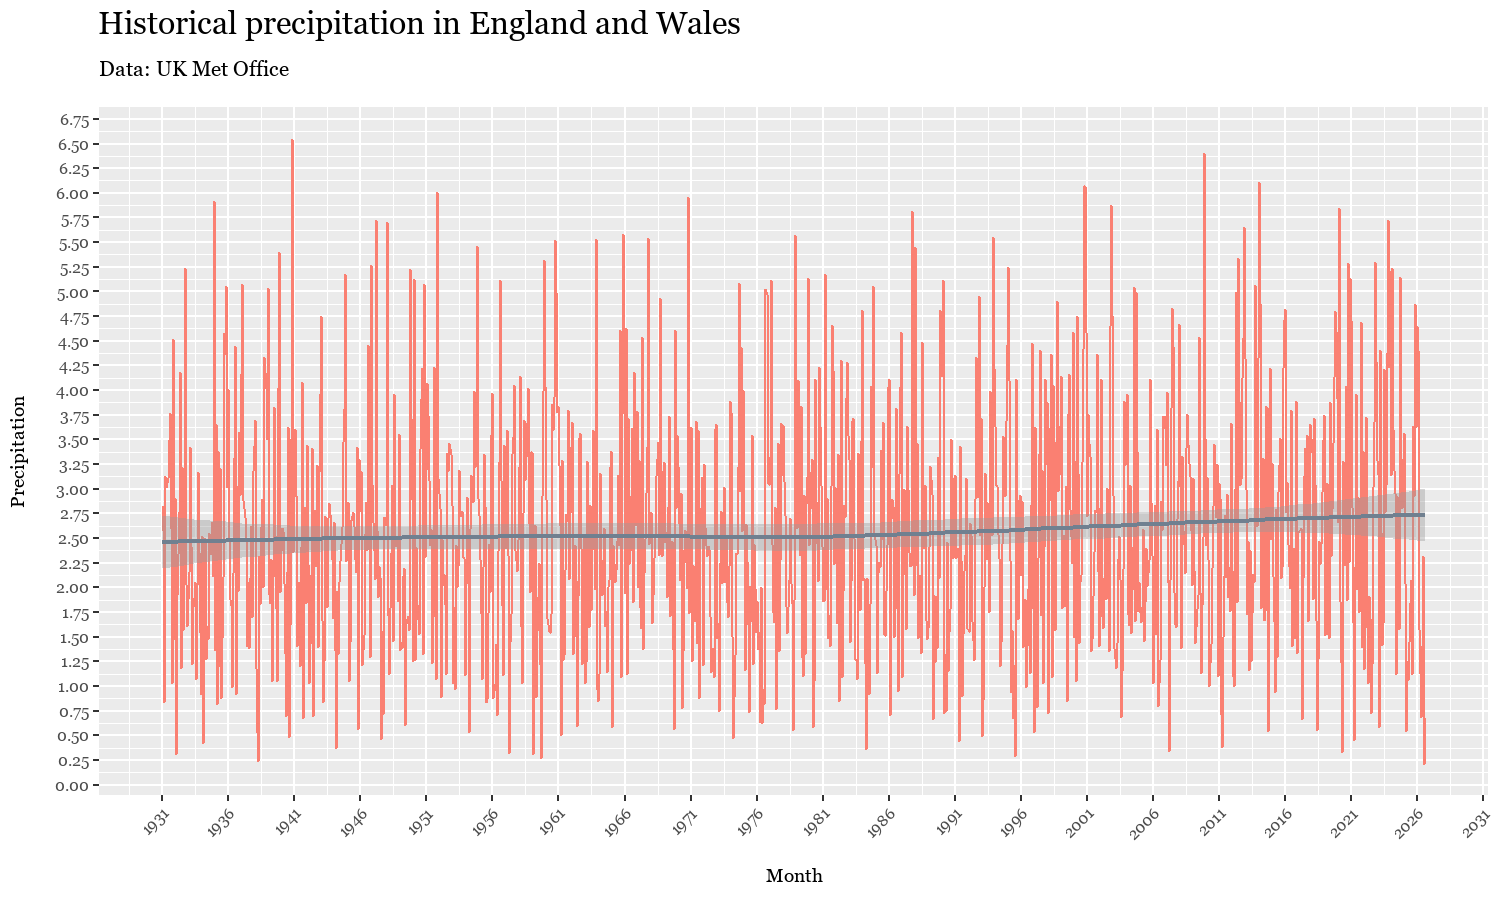

In [10]:
# Raw series (1931-2026)
df |>
    mutate(month = floor_date(date, "month")) |>
    group_by(month) |>
    summarise(
        monthly_avg = mean(precipitation, na.rm = TRUE),
        .groups = "drop"
    ) |>
    ggplot(aes(x = month, y = monthly_avg)) +
        geom_line(colour = "salmon") +
        geom_smooth(formula = "y ~ x", method = "loess", colour = "slategray") +
        scale_x_date(date_breaks = "5 years", date_labels = "%Y") +
        scale_y_continuous(breaks = scales::breaks_width(0.25)) +
        labs(
            title = "Historical precipitation in England and Wales",
            subtitle = "Data: UK Met Office",
            x = "Month",
            y = "Precipitation",
            colour = NULL
        ) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
        gen_theme()

There appears to be a mild, perceptible incline along the length of the series. The slope appears to increase as of approximately 1995.

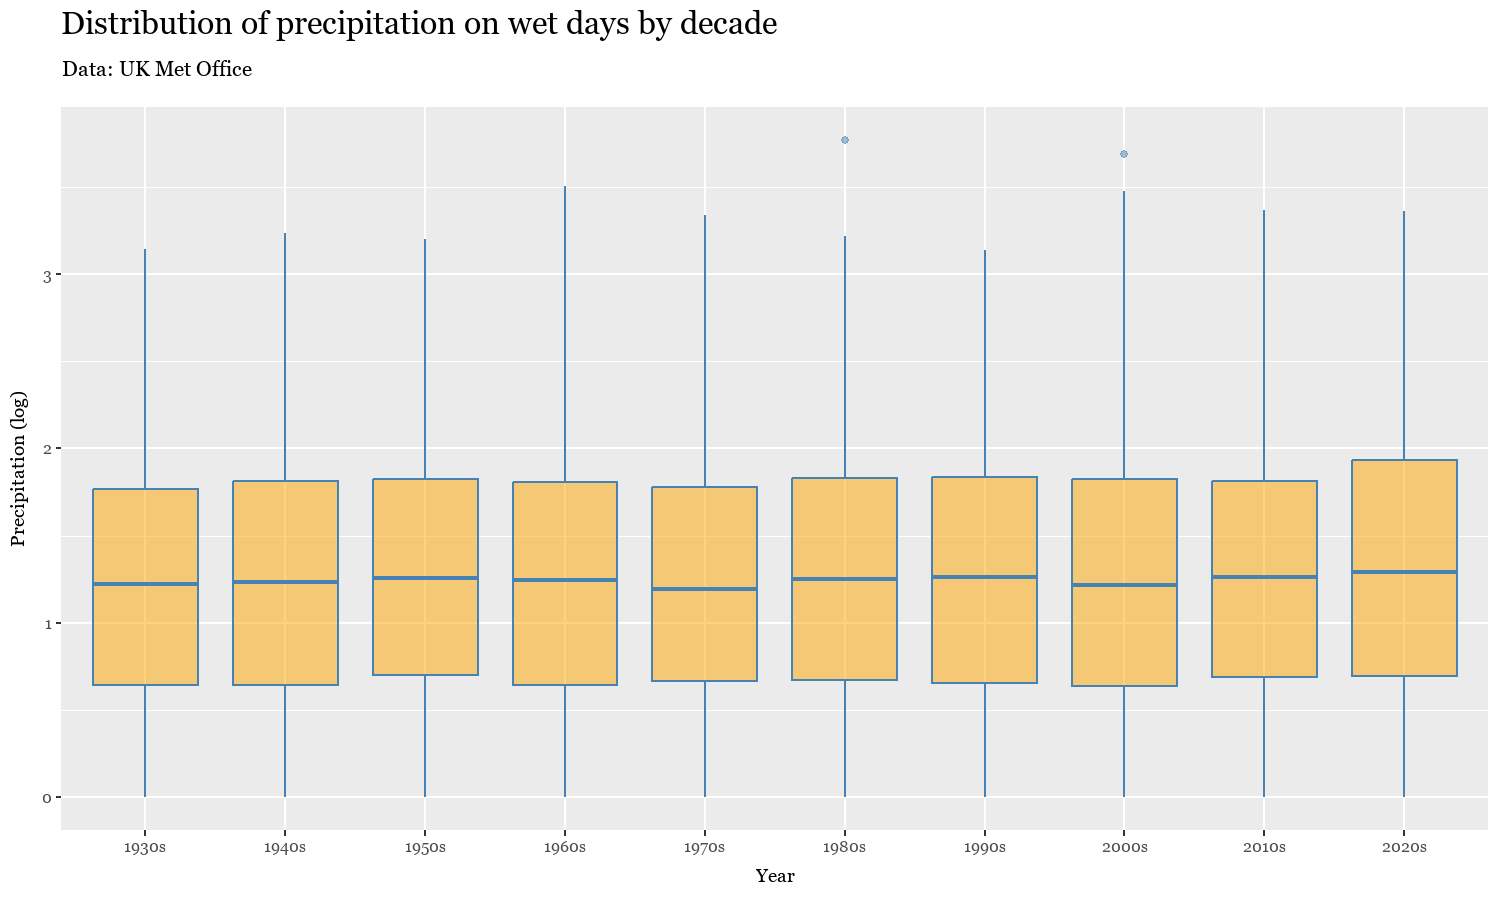

In [11]:
# Boxplots
df |>
    filter(precipitation >= 1) |>
    mutate(
        log_precipitation = log(precipitation),
        decade = paste0(year(date) %/% 10 * 10, "s")
    ) |>
    ggplot(aes(x = decade, y = log_precipitation, group = decade)) +
        geom_boxplot(colour = "steelblue", fill = "orange", alpha = 0.5) + 
        #geom_violin(colour = "steelblue", fill = "orange", alpha = 0.5) + 
        labs(
            title = "Distribution of precipitation on wet days by decade",
            subtitle = "Data: UK Met Office",
            x = "Year",
            y = "Precipitation (log)"
        ) +
        gen_theme()

Box-plots binned by decade suggest a mild incline from 2000 on with a noticeable step in the 2020s.

In [12]:
# Rolling statistics
window <- 365

roll_df <- df |>
    mutate(
        roll_mean = rollmean(precipitation, k = window, fill = NA, align = "right"),
        roll_sd = rollapply(precipitation, width = window, FUN = sd, fill = NA, align = "right"),
        roll_median = rollmedian(precipitation, k = window, fill = NA, align = "right"),
        roll_mad = rollapply(precipitation, width = window, FUN = mad, fill = NA, align = "right"),
        roll_max = rollmax(precipitation, k = window, fill = NA, align = "right"),
        roll_ratio = roll_max / roll_mean,
        roll_q95 = rollapply(precipitation, width = window, FUN = \(x) quantile(x, 0.95), fill = NA, align = "right")
    ) |>
    select(-c("roll_max")) |>
    pivot_longer(
        cols = starts_with("roll_"),
        names_to = "var",
        values_to = "val"
    ) |>
    drop_na() |>
    mutate(
        label = case_when(
            var == "roll_mean" ~ "Average",
            var == "roll_sd" ~ "Standard deviation",
            var == "roll_median" ~ "Median",
            var == "roll_mad" ~ "Median absolute deviation",
            var == "roll_q95" ~ "95th quantile",
            var == "roll_ratio" ~ "Max/mean ratio",
            .default = var
        )
    )

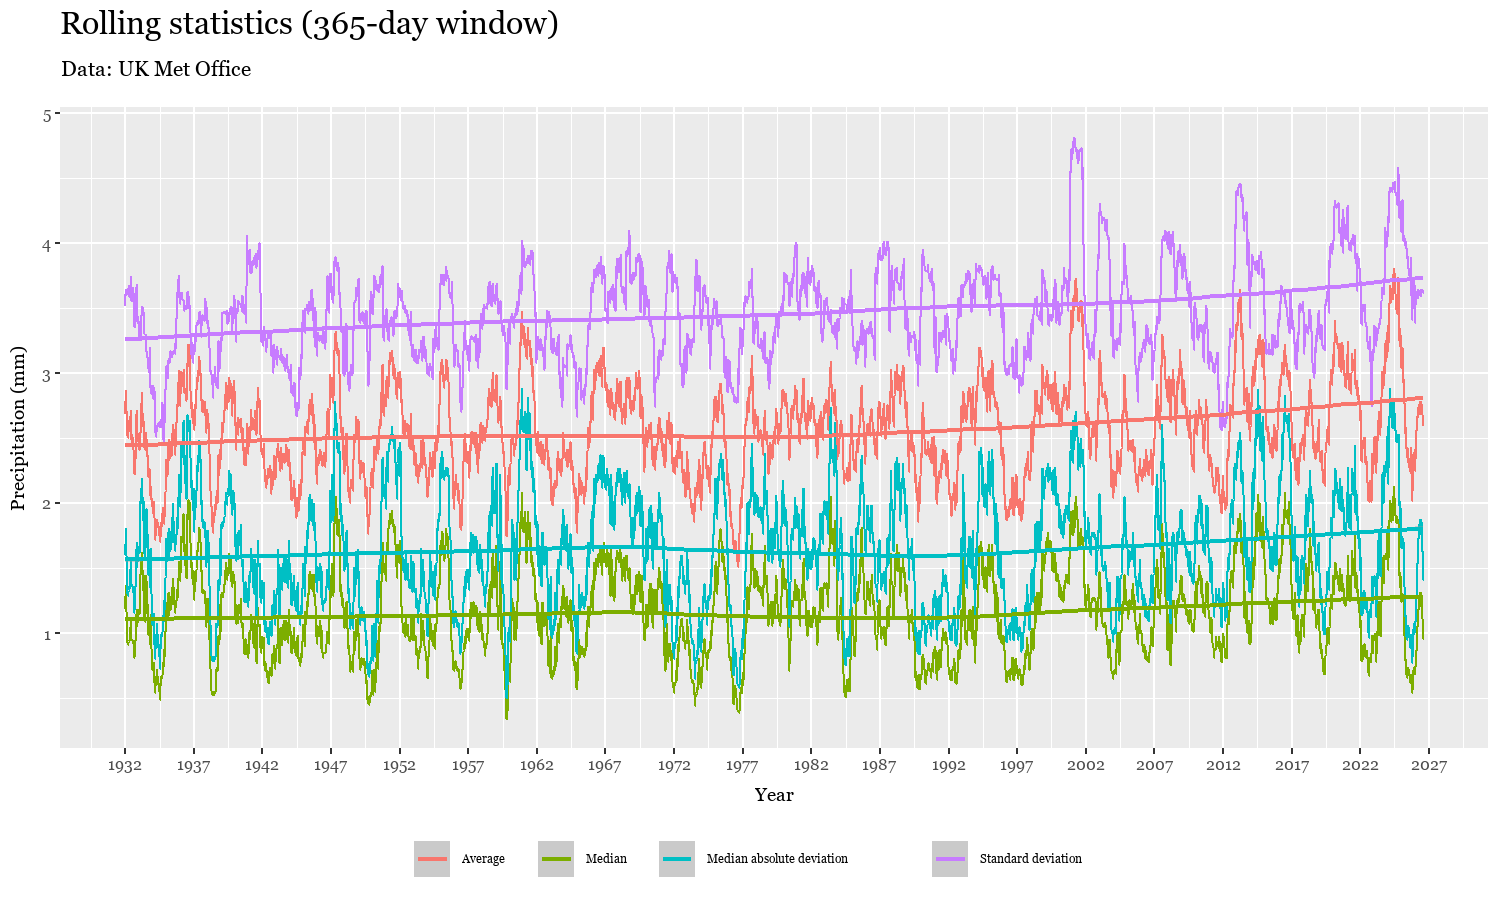

In [13]:
roll_df |> 
    filter(!var %in% c("roll_q95", "roll_ratio")) |>
    ggplot(aes(x = date, y = val, colour = label)) + 
        geom_line() +
        geom_smooth(method = "loess", formula = "y ~ x") +
        scale_x_date(date_breaks = "5 years", date_labels = "%Y") +
        scale_y_continuous(breaks = scales::breaks_width(1)) +
        guides(colour = guide_legend(title = NULL, nrow = 1)) +
        labs(
            title = "Rolling statistics (365-day window)",
            subtitle = "Data: UK Met Office",
            x = "Year",
            y = "Precipitation (mm)"
        ) +
        gen_theme(legend = "bottom")

Rolling statistics show the like modest incline over the years. The increase seems to take off about the year 2000.

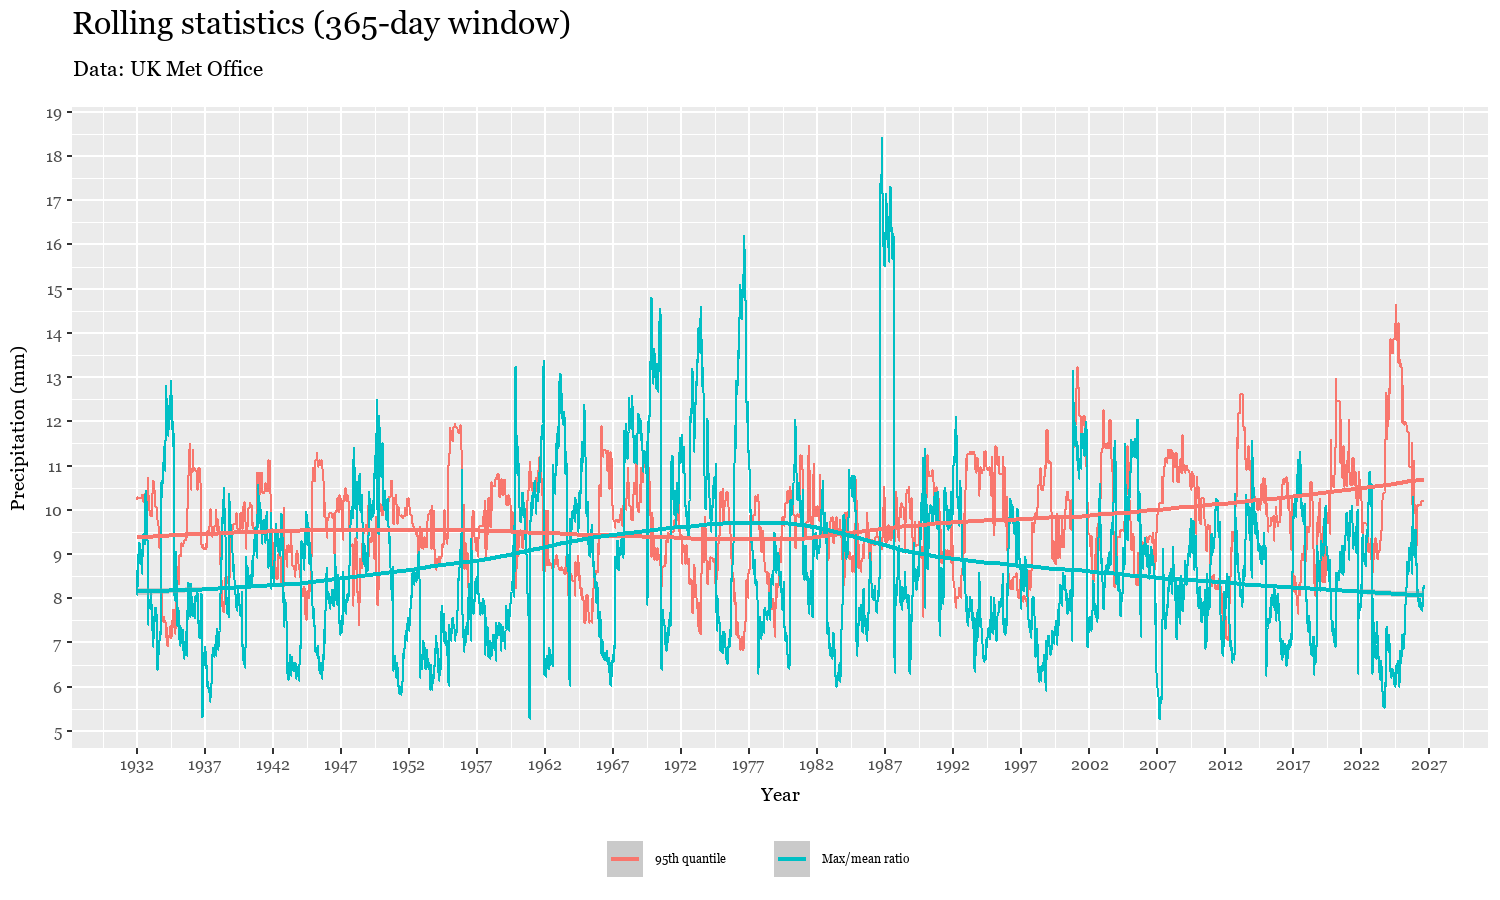

In [14]:
roll_df |> 
    filter(var %in% c("roll_q95", "roll_ratio")) |>
    ggplot(aes(x = date, y = val, colour = label)) + 
        geom_line() +
        geom_smooth(method = "loess", formula = "y ~ x") +
        scale_x_date(date_breaks = "5 years", date_labels = "%Y") +
        scale_y_continuous(breaks = scales::breaks_width(1)) +
        guides(colour = guide_legend(title = NULL, nrow = 1)) +
        labs(
            title = "Rolling statistics (365-day window)",
            subtitle = "Data: UK Met Office",
            x = "Year",
            y = "Precipitation (mm)"
        ) +
        gen_theme(legend = "bottom")

The same pattern is only the more pronounced in the rolling 95th quantile, which has a perceptibly steep rise towards the tail end. The late 60s and early 70s were dominated by extremes, but the maxima-to-mean apper to have settled back on what seems to have been normal before.

In [15]:
# Investigate the spike around 1986 or so
df |>
    filter(year(date) > "1984" & year(date) < "1991") |>
    filter(precipitation == max(precipitation))

date,precipitation
<date>,<dbl>
1986-08-25,43.23


Plot variable not specified, automatically selected `y = precipitation`


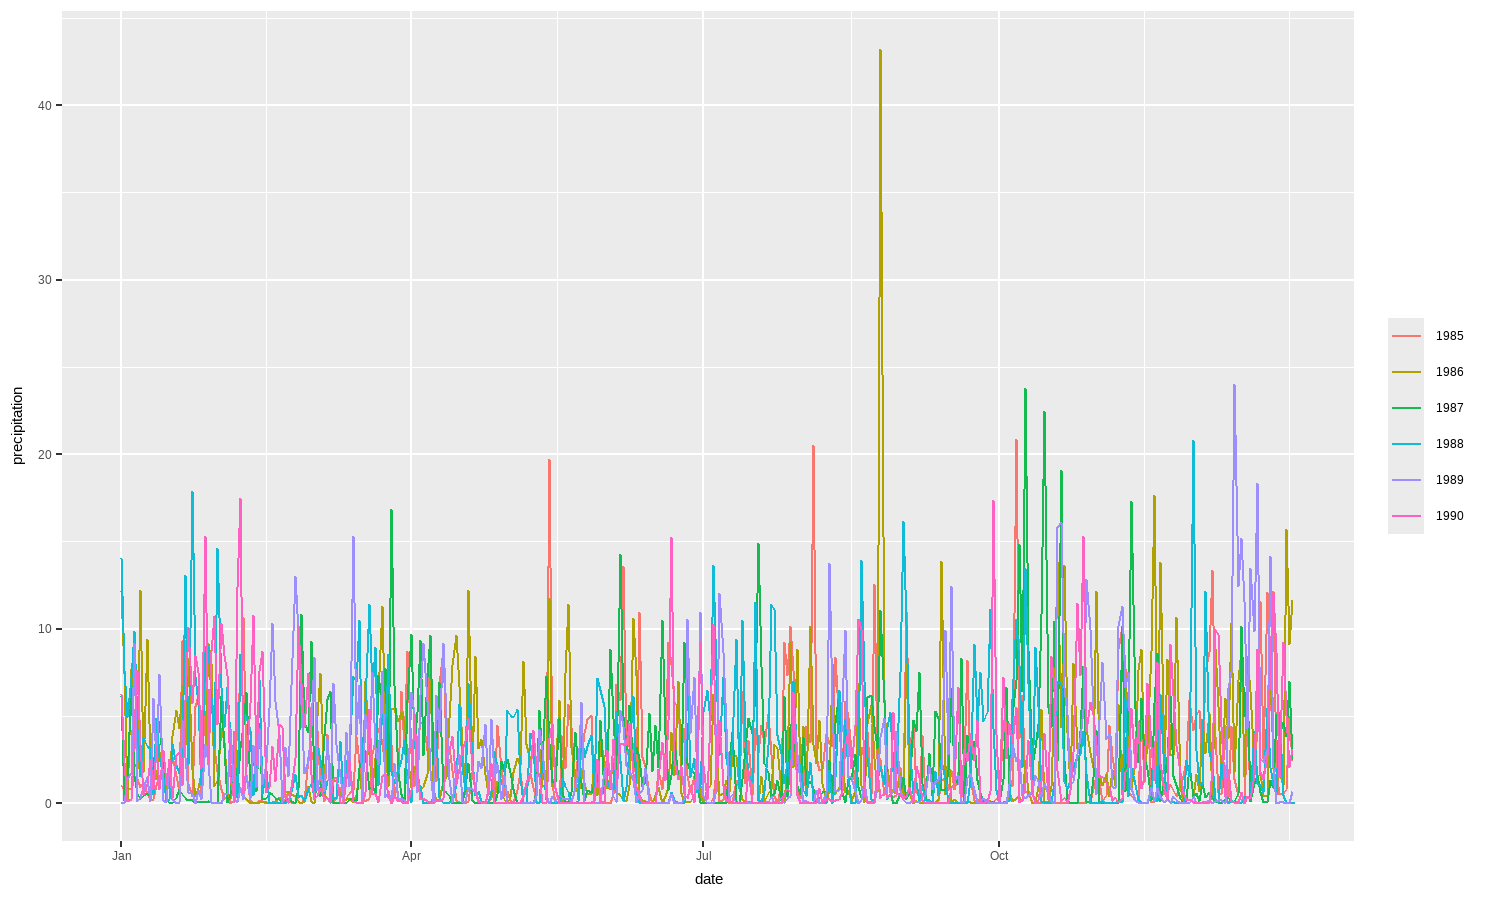

In [16]:
# Investigate the context around the spike
df |>
    filter(year(date) > "1984" & year(date) < "1991") |>
    as_tsibble(index = date) |>
    index_by(month = ~ yearmonth(.x)) |>
    gg_season()

The spike around 1987 seems to have been driven by a single event in August of 1986. This was the day [Hurricane Charlie](https://www.rmets.org/metmatters/wettest-day-record) hit the UK.

### 2000-2026

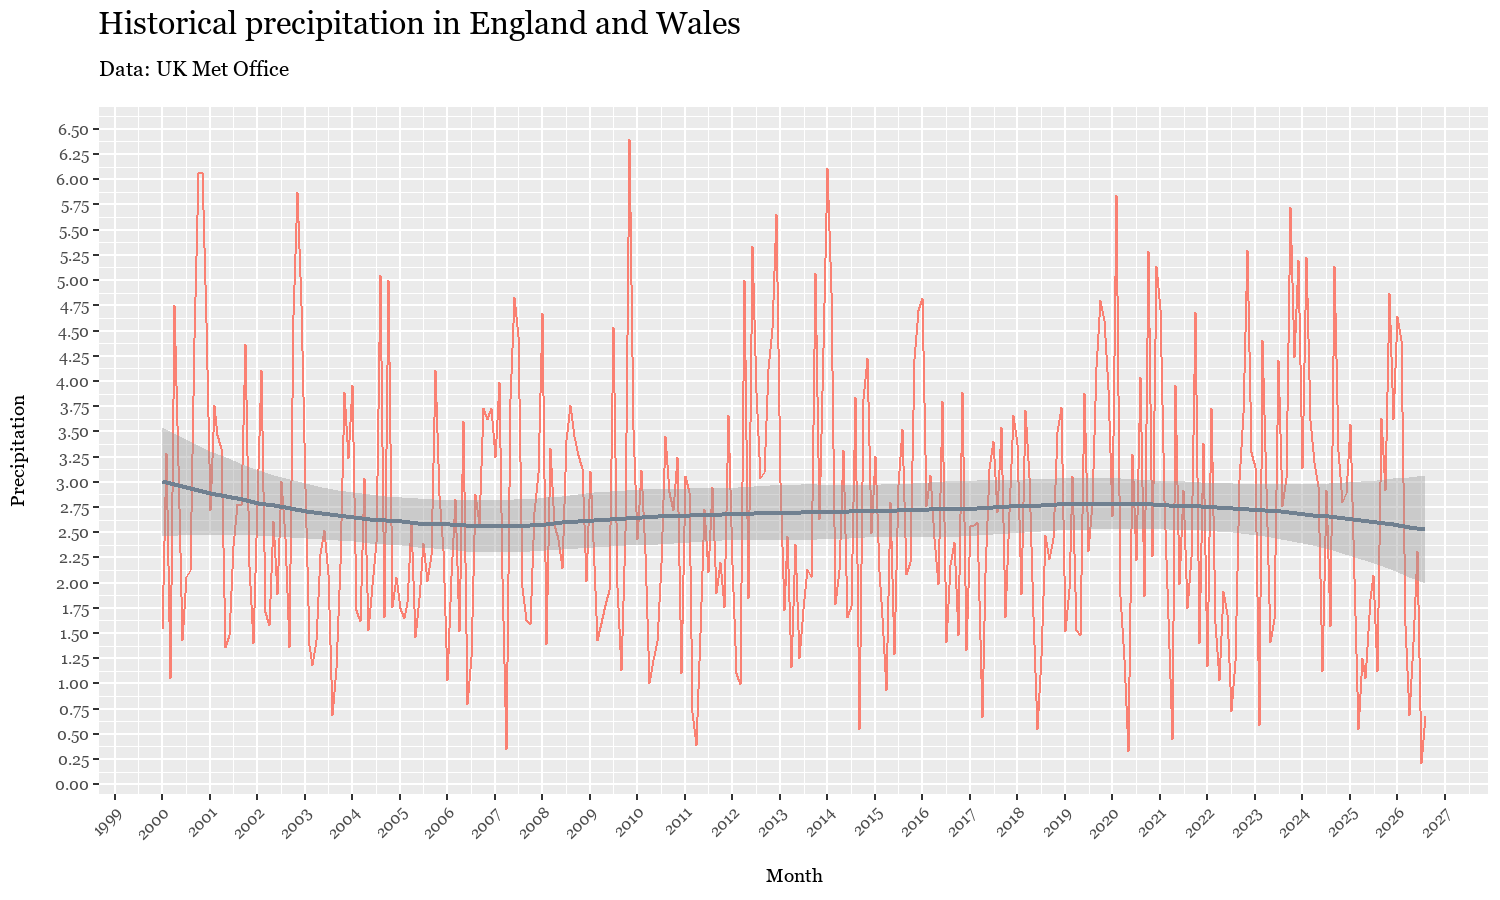

In [17]:
# Raw series (2000-2026)
df |>
    filter(date > "2000-01-01") |>
    mutate(month = floor_date(date, "month")) |>
    group_by(month) |>
    summarise(
        monthly_avg = mean(precipitation, na.rm = TRUE),
        .groups = "drop"
    ) |>
    ggplot(aes(x = month, y = monthly_avg)) +
        geom_line(colour = "salmon") +
        geom_smooth(formula = "y ~ x", method = "loess", colour = "slategray") +
        scale_x_date(date_breaks = "1 years", date_labels = "%Y") +
        scale_y_continuous(breaks = scales::breaks_width(0.25)) +
        labs(
            title = "Historical precipitation in England and Wales",
            subtitle = "Data: UK Met Office",
            x = "Month",
            y = "Precipitation",
            colour = NULL
        ) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
        gen_theme()

The upward trend gets lost in a shorter series spanning the two and a half decades after 2000.

Plot variable not specified, automatically selected `y = precipitation`


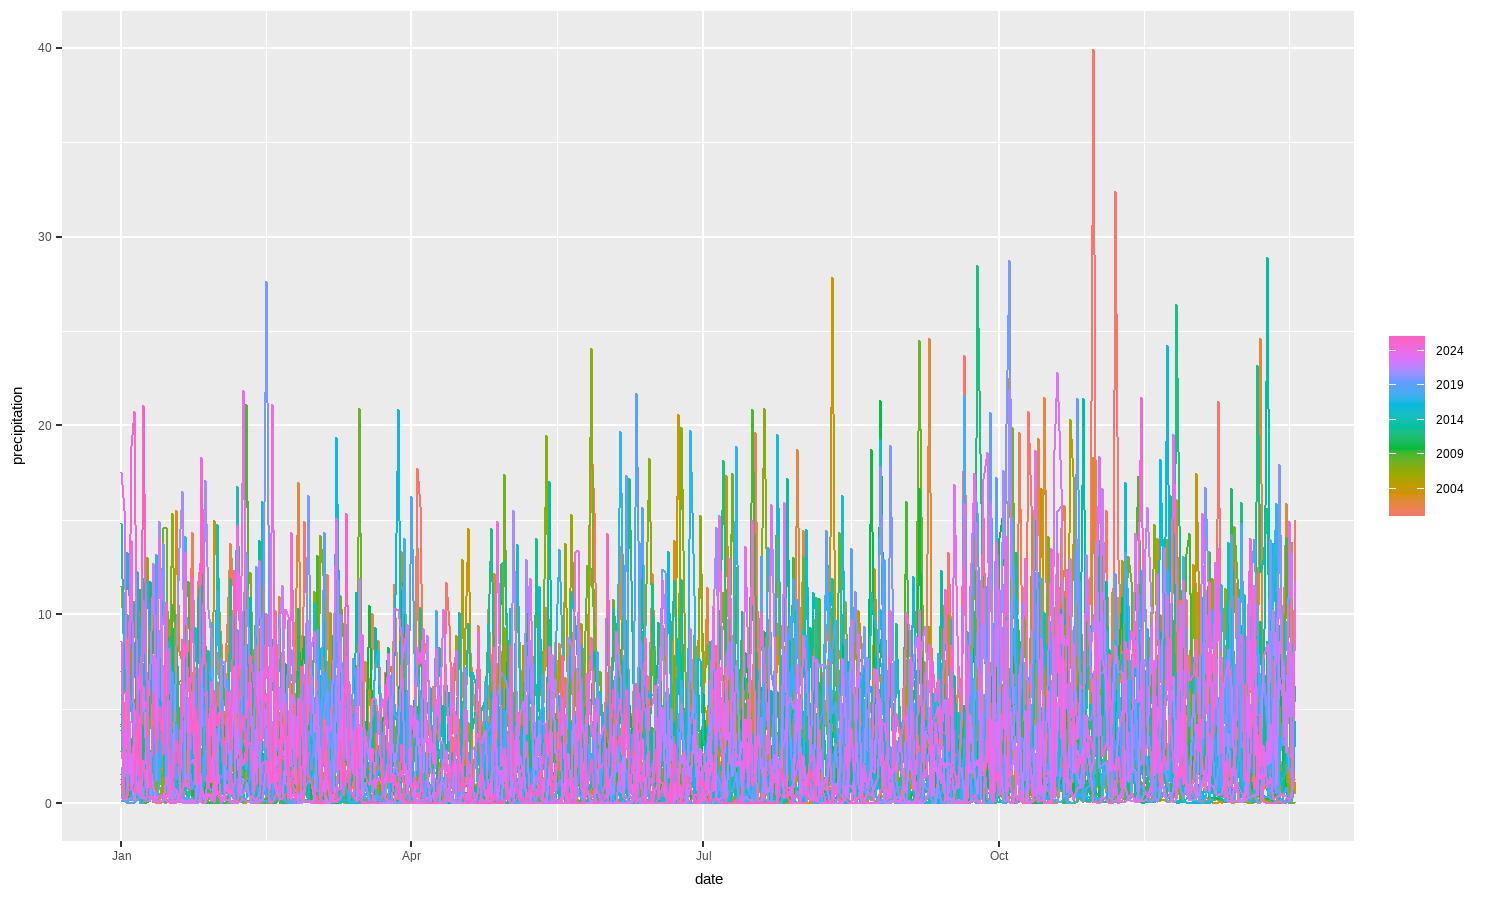

In [18]:
# Investigate seasonal patterns
df |>
    filter(date > "2000-01-01") |>
    as_tsibble(index = date) |>
    gg_season()

The peaks from recent years are, perhaps, visible in the yearly plot. A seasonal pattern is clearly discernible.

Plot variable not specified, automatically selected `y = avg_precipitation`


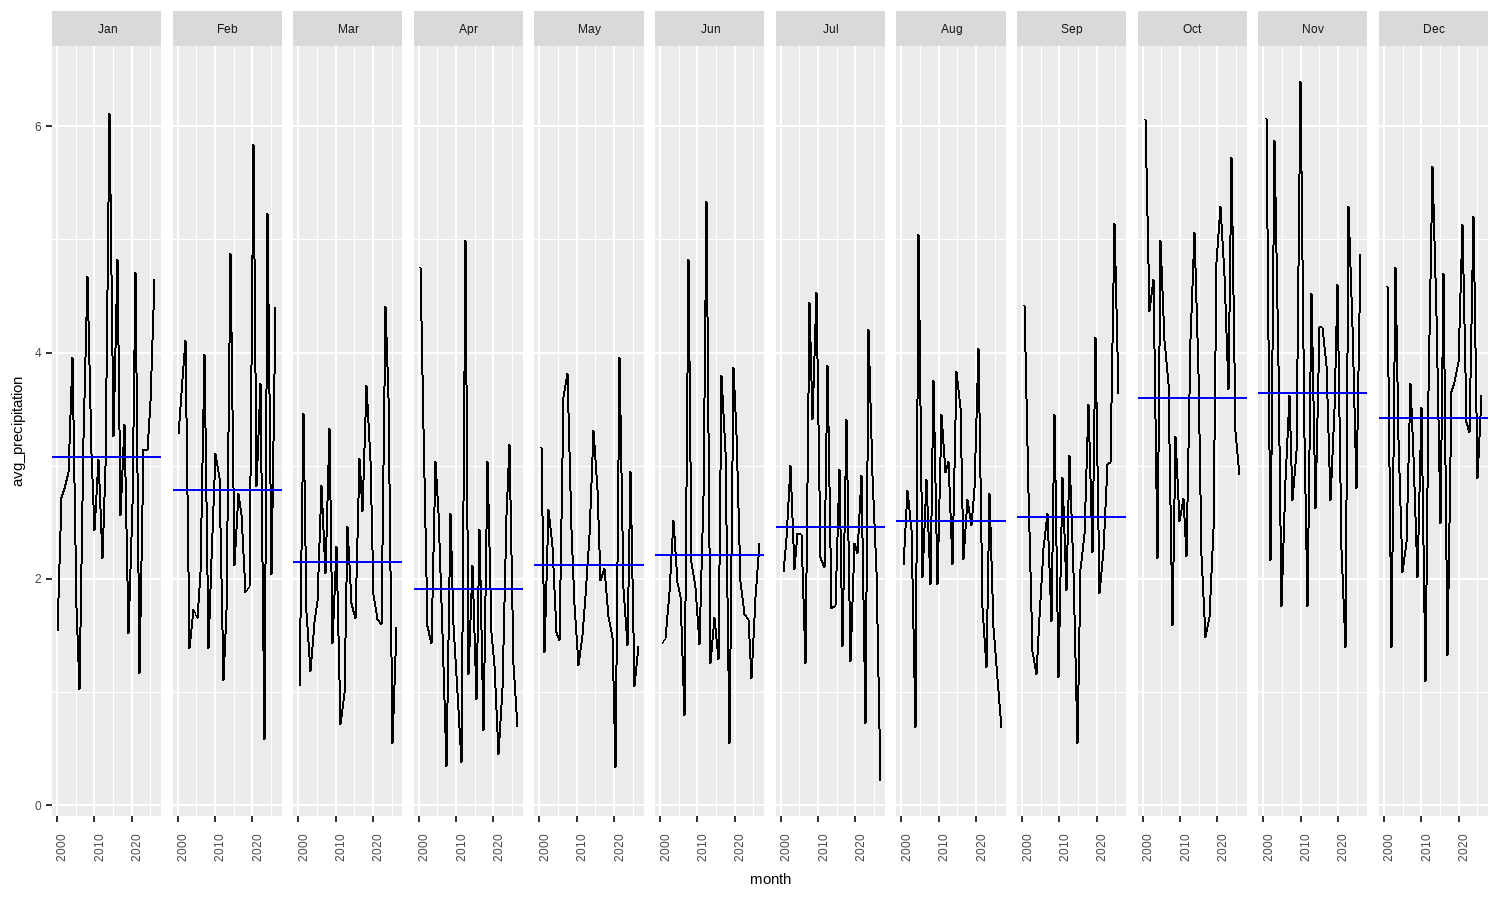

In [19]:
# Investigate seasonal patterns
df |>
    filter(date > "2000-01-01") |>
    as_tsibble(index = date) |>
    index_by(month = ~ yearmonth(.x)) |>
    summarise(avg_precipitation = mean(precipitation, na.rm = TRUE)) |>
    gg_subseries()

Broken down by month, the series has a clear seasonal pattern with precipitation being highest in November and lowest in April. The April average may be dragged up by extremes.

## 4. Very wet days

In this section, we compute the count and total precipitation on very wet days. Very wet days are defined by the R95p index as days whose precipitation falls into the top five percentiles of the base period. We draw on [Climdex](https://www.climdex.org/learn/indices/#index-R95p), which locates the base period between 1961 and 1990.

In [20]:
# very_wet_days, R95p, R10 and R20 wrapper
yearly_threshold_stat <- function(df, condition, stat = c("count", "sum")) {
    stat <- match.arg(stat)
    out <- df |>
        filter({{ condition }}) |>
        mutate(year = year(date)) |>
        group_by(year)

    if (stat == "count") out |> summarise(n = n(), .groups = "drop")
    else out |> summarise(total = sum(precipitation), .groups = "drop")
}

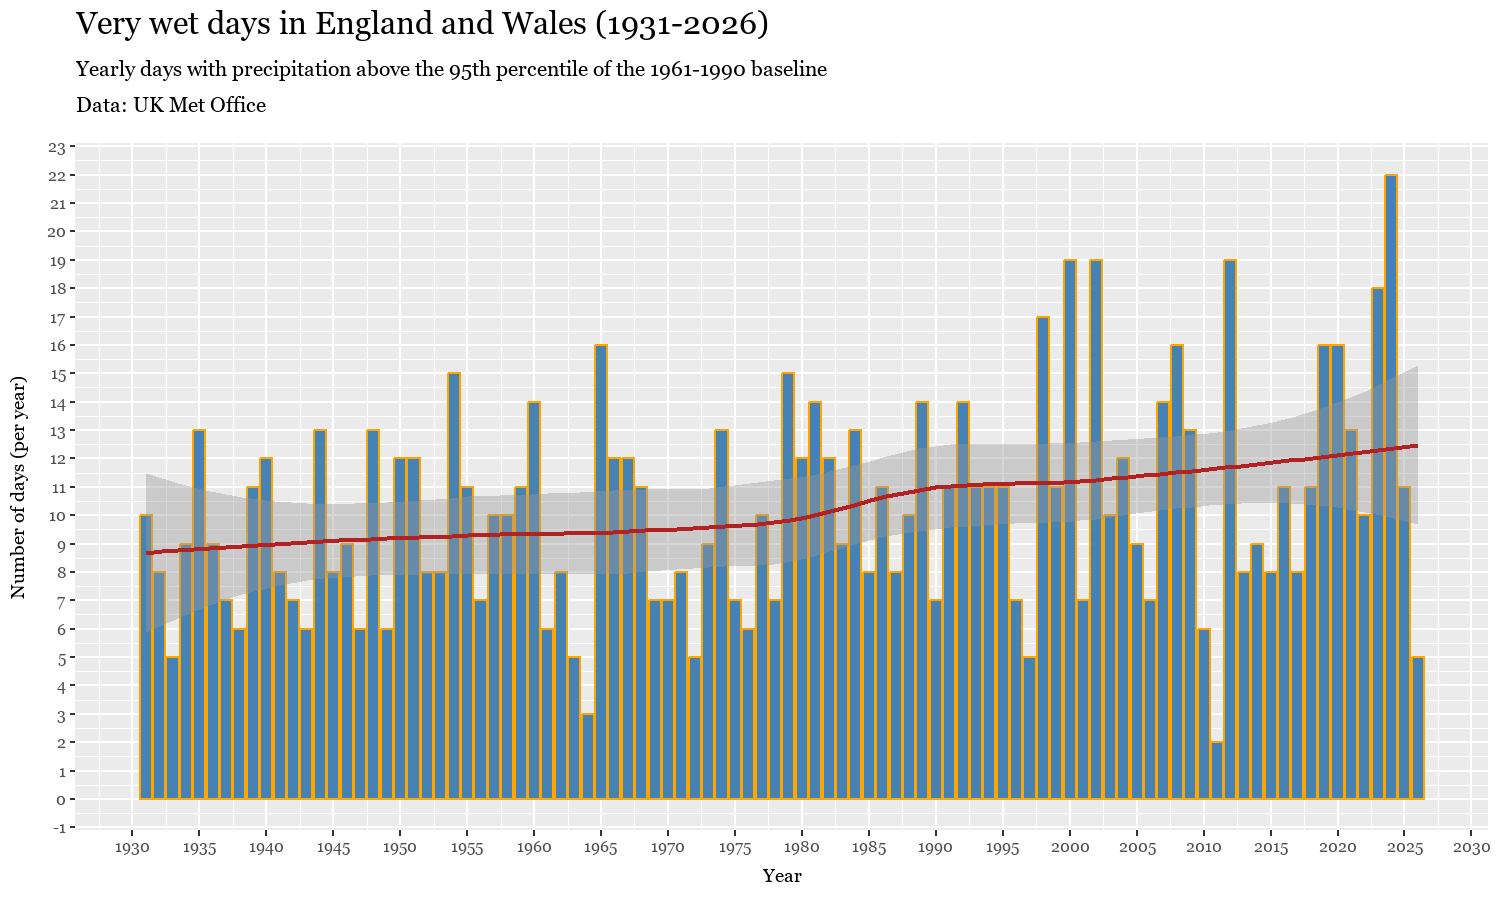

In [21]:
# Tally of very wet days
RR_wj_95 <- df |>
    filter(precipitation >= 1) |>
    filter(year(date) > "1960" & year(date) < "1991") |>
    summarise(q95 = quantile(precipitation, p = .95, na.rm = TRUE)) |>
    pull()

very_wet_days <- df |>
    yearly_threshold_stat(precipitation > RR_wj_95, stat = "count")

very_wet_days |>
    ggplot(aes(x = year, y = n)) + 
    geom_col(colour = "orange", fill = "steelblue") + 
    geom_smooth(method = "loess", formula = "y ~ x", colour = "firebrick") +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(1)) + 
    labs(
        title = "Very wet days in England and Wales (1931-2026)",
        subtitle = "Yearly days with precipitation above the 95th percentile of the 1961-1990 baseline\nData: UK Met Office",
        x = "Year",
        y = "Number of days (per year)"
    ) +
    gen_theme()

The count of wet days with precipitation in the top five percentiles has an obvious upward trend.

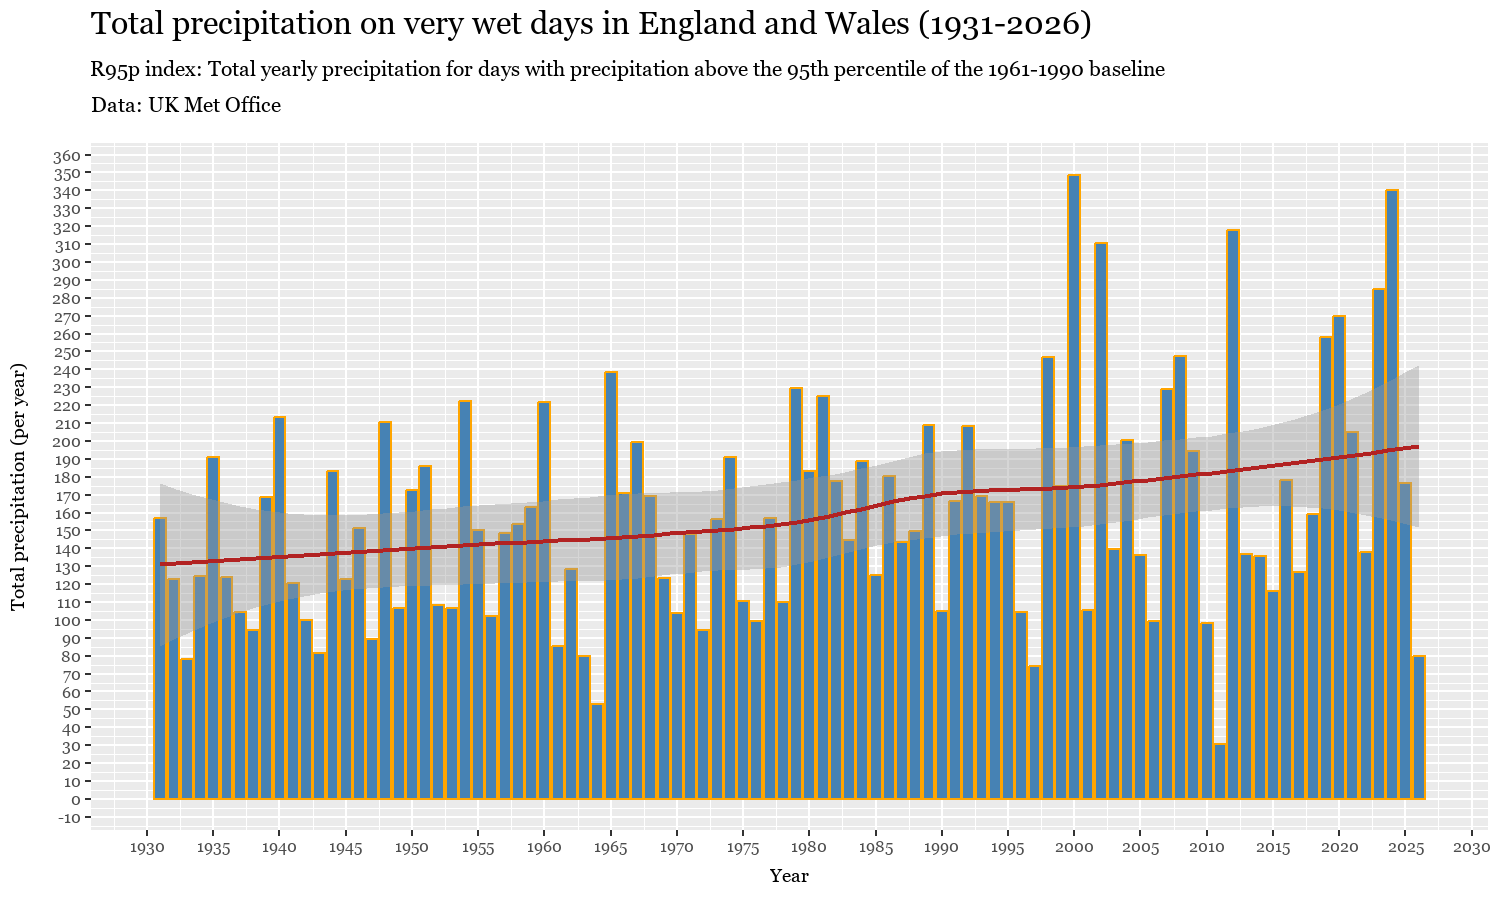

In [22]:
# Total precipitation on very wet days
R95p <- df |>
    yearly_threshold_stat(precipitation > RR_wj_95, stat = "sum")

R95p |>
    ggplot(aes(x = year, y = total)) + 
    geom_col(colour = "orange", fill = "steelblue") + 
    geom_smooth(method = "loess", formula = "y ~ x", colour = "firebrick") +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(10)) + 
    labs(
        title = "Total precipitation on very wet days in England and Wales (1931-2026)",
        subtitle = "R95p index: Total yearly precipitation for days with precipitation above the 95th percentile of the 1961-1990 baseline\nData: UK Met Office",
        x = "Year",
        y = "Total precipitation (per year)"
    ) +
    gen_theme()

So does total precipitation. It seems that looking at the upper extremes can tell us something meaningful.

## 5. Consecutive dry and wet days

In this section, we compute the day counts of dry and wet spells. A dry spell (CDD index) is defined as a continuous run of days with precipitation below 1 mm. A wet spell (CWD index) is a string of days with precipitation of or higher than 1 mm.

Credit for the consecutive days tally solution: [acylam (StackOverflow)](https://stackoverflow.com/questions/54463950/r-count-consecutive-days-with-condition).

In [23]:
# CDD and CWD pipeline wrapper
max_run_by_year <- function(df, condition) {
    df |>
        mutate(year = year(date), flag = {{ condition }}, id = data.table::rleid(flag)) |>
        group_by(year, id) |>
        mutate(run_len = if_else(flag, row_number(), 0L)) |>
        ungroup() |>
        group_by(year) |>
        summarise(max_run = max(run_len), .groups = "drop")
}

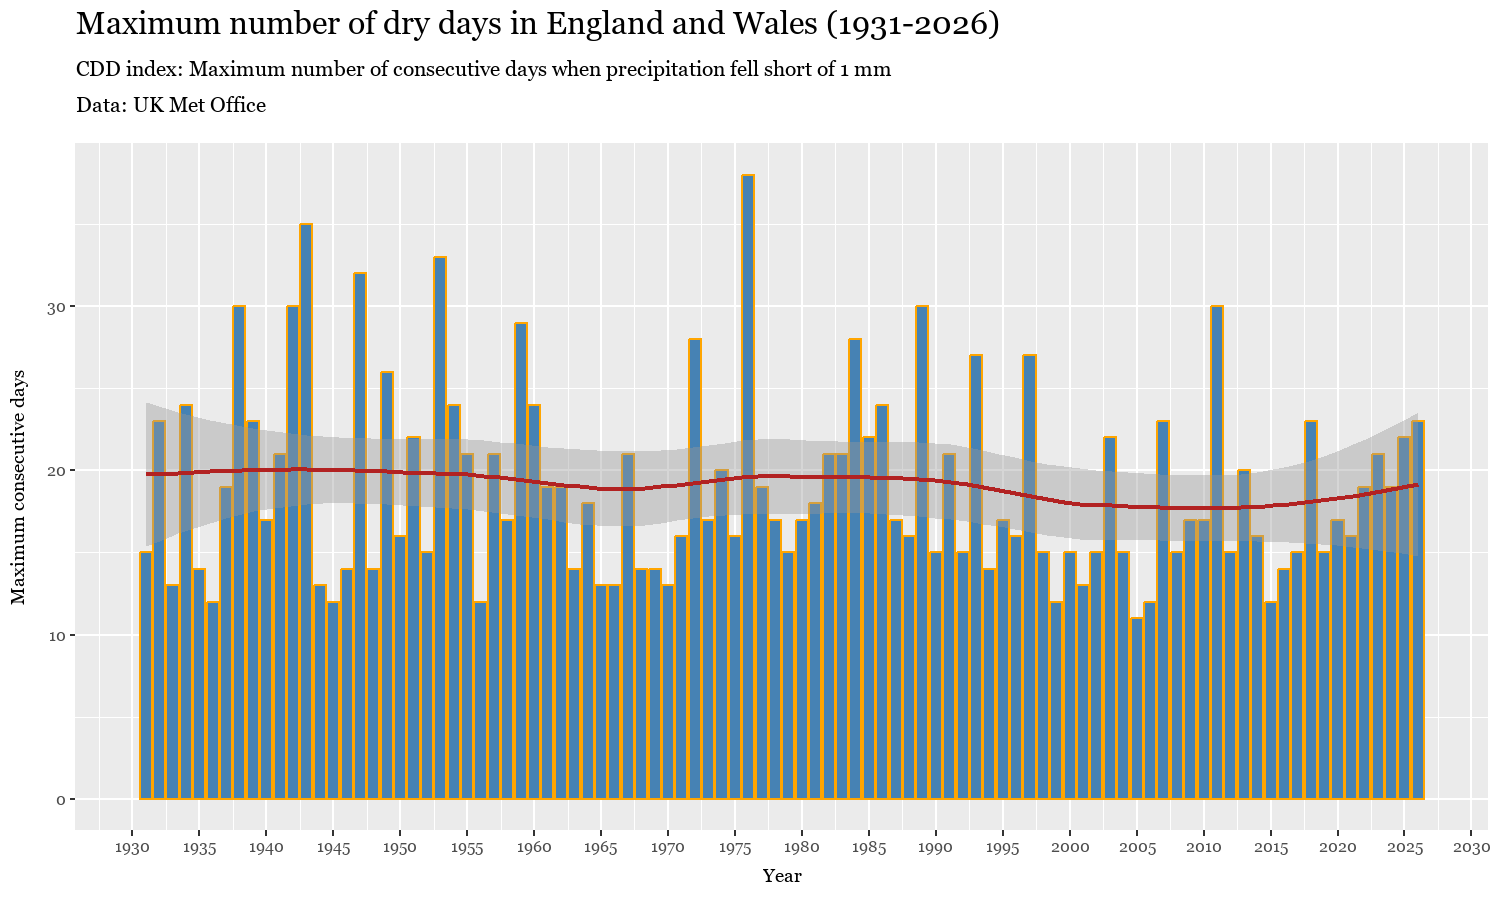

In [24]:
CDD <- df |> 
    max_run_by_year(precipitation < 1) |> 
    rename(cdd = max_run)

CDD |>
    ggplot(aes(x = year, y = cdd)) + 
    geom_col(colour = "orange", fill = "steelblue") + 
    geom_smooth(method = "loess", formula = "y ~ x", colour = "firebrick") +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(10)) + 
    labs(
        title = "Maximum number of dry days in England and Wales (1931-2026)",
        subtitle = "CDD index: Maximum number of consecutive days when precipitation fell short of 1 mm\nData: UK Met Office",
        x = "Year",
        y = "Maximum consecutive days"
    ) +
    gen_theme()

The count of dry days, defined as days with precipitation below 1 mm, seems to show a barely perceptible decline with an uplift towards its tail end.

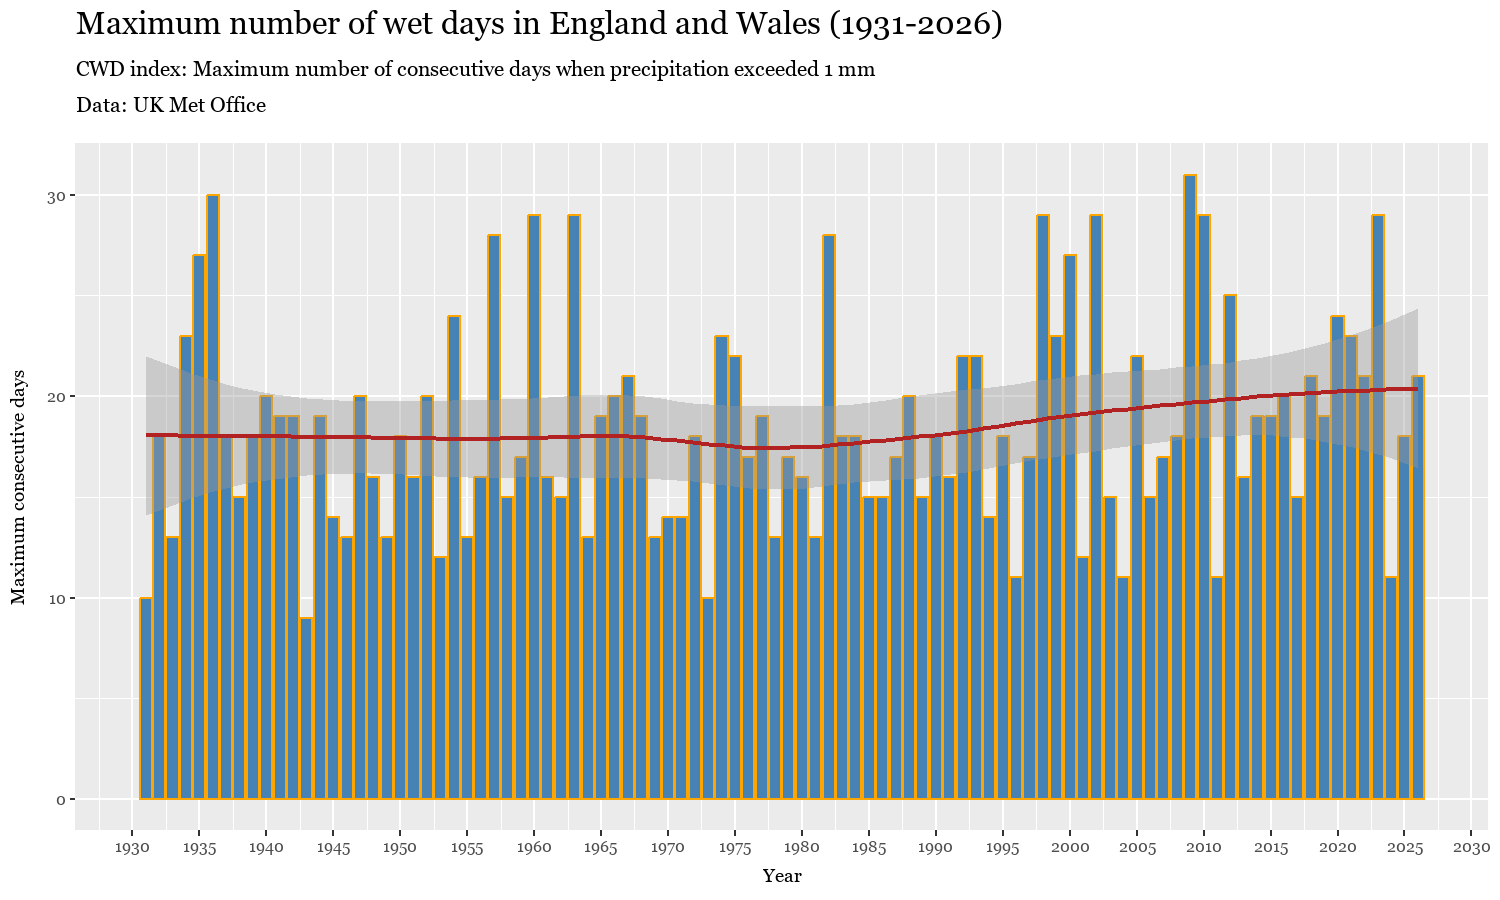

In [25]:
CWD <- df |>
    max_run_by_year(precipitation >= 1) |> 
    rename(cwd = max_run)

CWD |>
    ggplot(aes(x = year, y = cwd)) + 
    geom_col(colour = "orange", fill = "steelblue") + 
    geom_smooth(method = "loess", formula = "y ~ x", colour = "firebrick") +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(10)) + 
    labs(
        title = "Maximum number of wet days in England and Wales (1931-2026)",
        subtitle = "CWD index: Maximum number of consecutive days when precipitation exceeded 1 mm\nData: UK Met Office",
        x = "Year",
        y = "Maximum consecutive days"
    ) +
    gen_theme()

And the count of wet days, defined as days when precipitation exceeded 1 mm, has an opposing, but similarly negligible trend.

## 6. Heavy precipitation

Now we turn to visually analysing the counts of days which saw heavy precipitation (in excess of 10 mm) and very heavy precipitation (in excess of 20 mm). The climate literature names these indices R10 and R20, respectively.

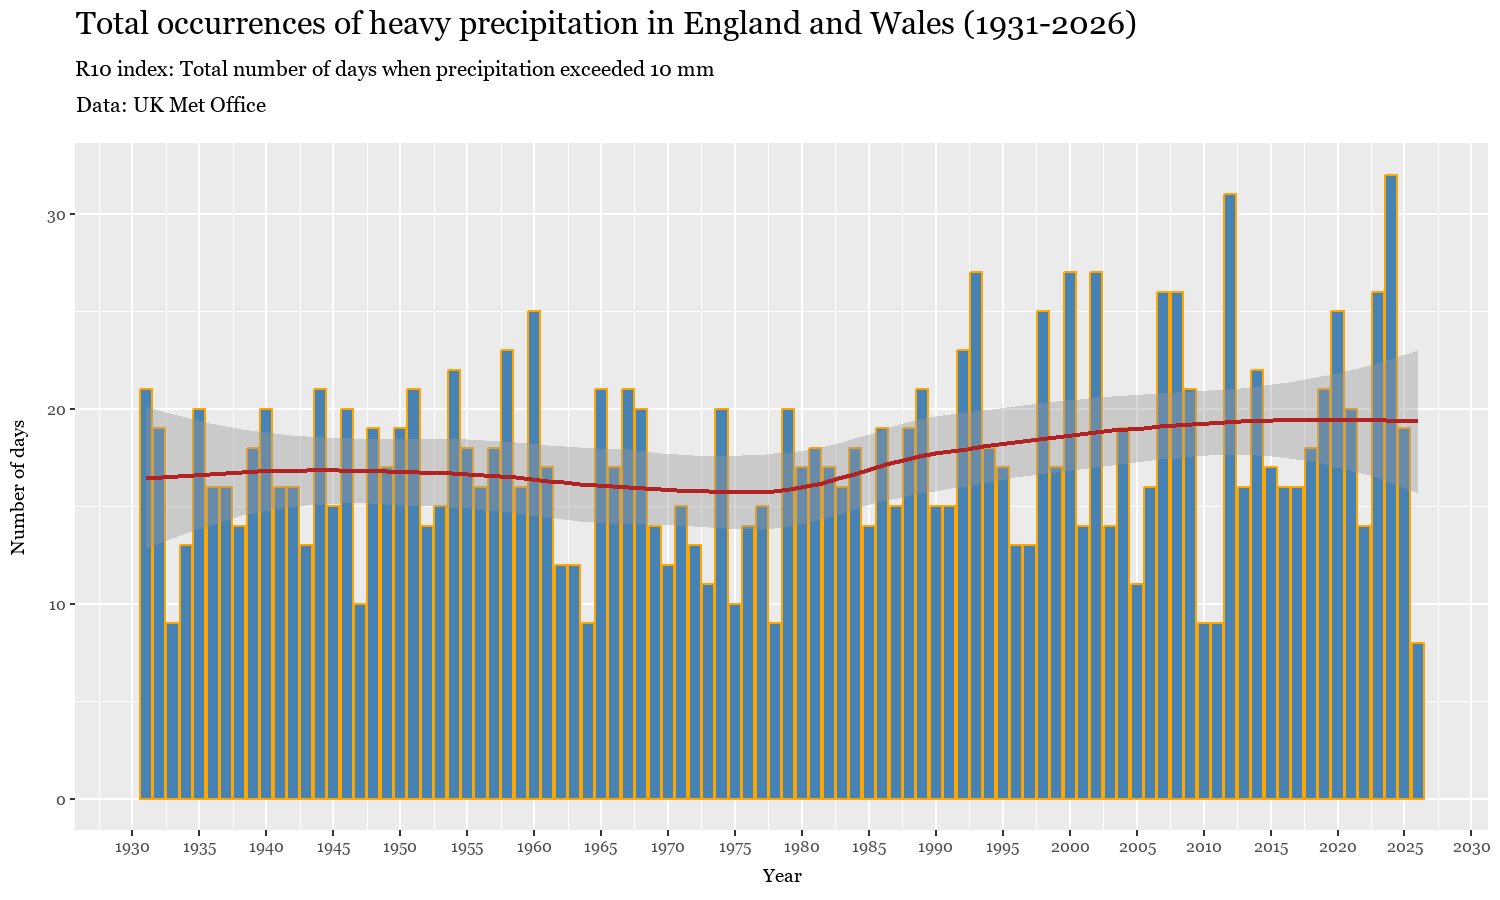

In [26]:
R10 <- df |>
    yearly_threshold_stat(precipitation >= 10, stat = "count")

R10 |>
    ggplot(aes(x = year, y = n)) + 
    geom_col(colour = "orange", fill = "steelblue") + 
    geom_smooth(method = "loess", formula = "y ~ x", colour = "firebrick") +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(10)) + 
    labs(
        title = "Total occurrences of heavy precipitation in England and Wales (1931-2026)",
        subtitle = "R10 index: Total number of days when precipitation exceeded 10 mm\nData: UK Met Office",
        x = "Year",
        y = "Number of days"
    ) +
    gen_theme()

The tally of days on which precipitation exceeded 10 mm seems to have been rising since about 1980 but has flattened out since.

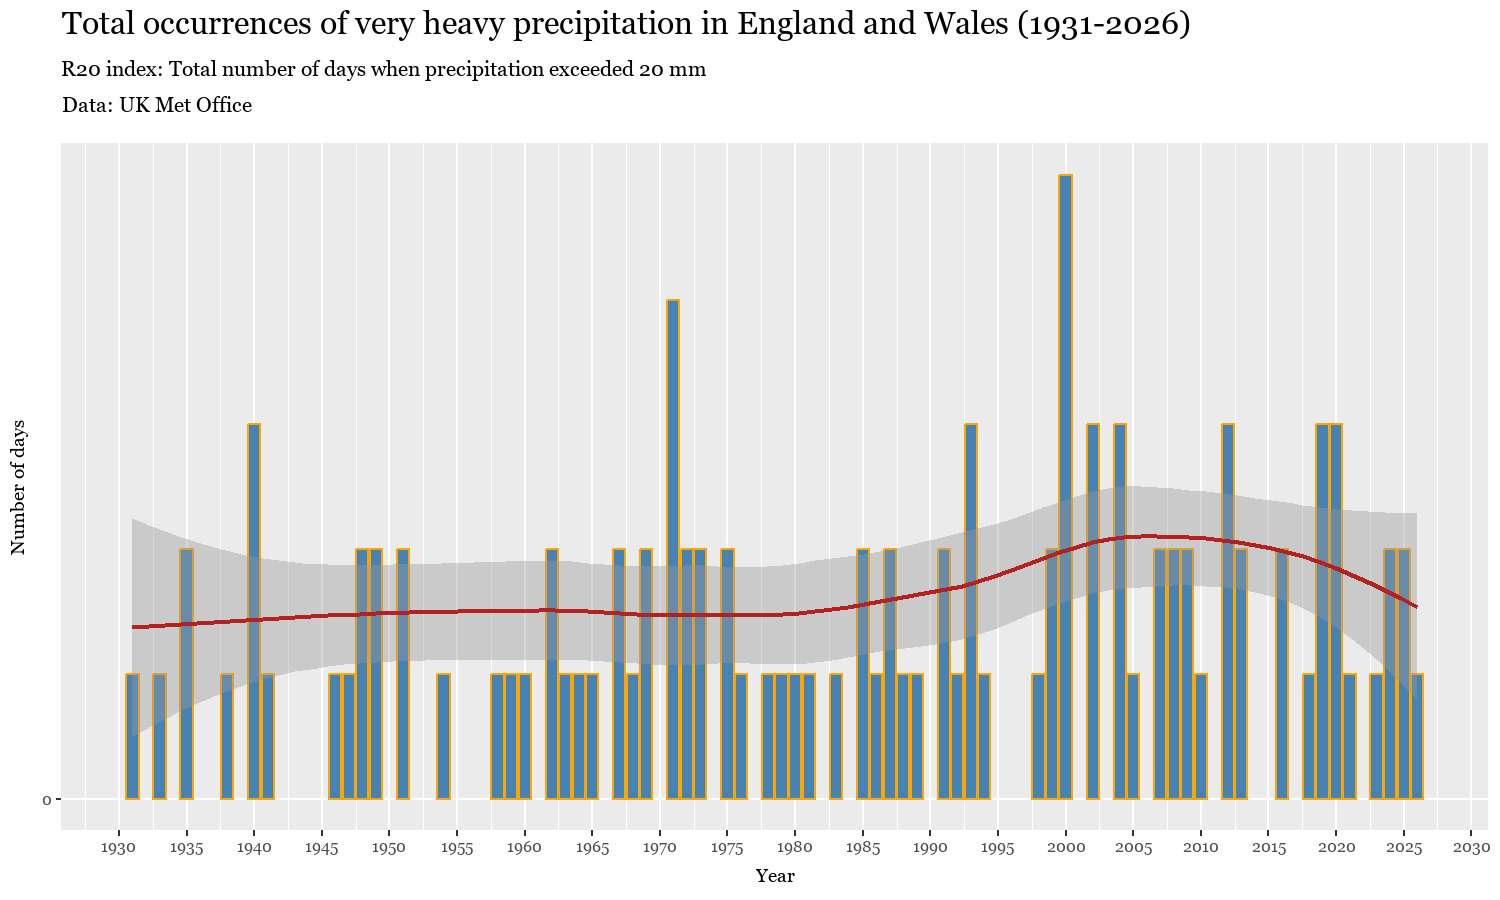

In [27]:
R20 <- df |>
    yearly_threshold_stat(precipitation >= 20, stat = "count")
    
R20 |>
    ggplot(aes(x = year, y = n)) + 
    geom_col(colour = "orange", fill = "steelblue") + 
    geom_smooth(method = "loess", formula = "y ~ x", colour = "firebrick") +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(10)) + 
    labs(
        title = "Total occurrences of very heavy precipitation in England and Wales (1931-2026)",
        subtitle = "R20 index: Total number of days when precipitation exceeded 20 mm\nData: UK Met Office",
        x = "Year",
        y = "Number of days"
    ) +
    gen_theme()

Occurrences of precipitation above 20 mm have been noticeably more frequent since 2000, which [has seen a record](https://www.rmets.org/metmatters/wettest-day-record).

## 7. Precipitation clusters

In this section, we compute and plot the annual precipitation cluster index from the total and average monthly precipitation data. The plots will tell us about the consistency of the dispersion of precipitation over the years.

For this index, we omit the months of 2026 since the incomplete set inflates the index.

In [28]:
PCI <- df |>
    mutate(
        year = year(date),
        month = month(date, label = TRUE)
    ) |>
    group_by(year, month) |>
    summarise(
        monthly_avg = mean(precipitation, na.rm = TRUE),
        monthly_sum = sum(precipitation, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(
        monthly_avg_sq = monthly_avg^2,
        monthly_sum_sq = monthly_sum^2
    ) |>
    group_by(year) |>
    summarise(
        pci_avg = sum(monthly_avg_sq, na.rm = TRUE) / sum(monthly_avg, na.rm = TRUE)^2 * 100,
        pci_sum = sum(monthly_sum_sq, na.rm = TRUE) / sum(monthly_sum, na.rm = TRUE)^2 * 100,
        .groups = "drop"
    ) |>
    # Filter out incomplete year with overweighted index
    filter(year < "2026") |>
    pivot_longer(
        cols = starts_with("pci_"),
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        label = case_when(
            var == "pci_avg" ~ "PCI (average monthly precipitation)",
            var == "pci_sum" ~ "PCI (total monthly precipitation)",
            .default = var
        )
    )

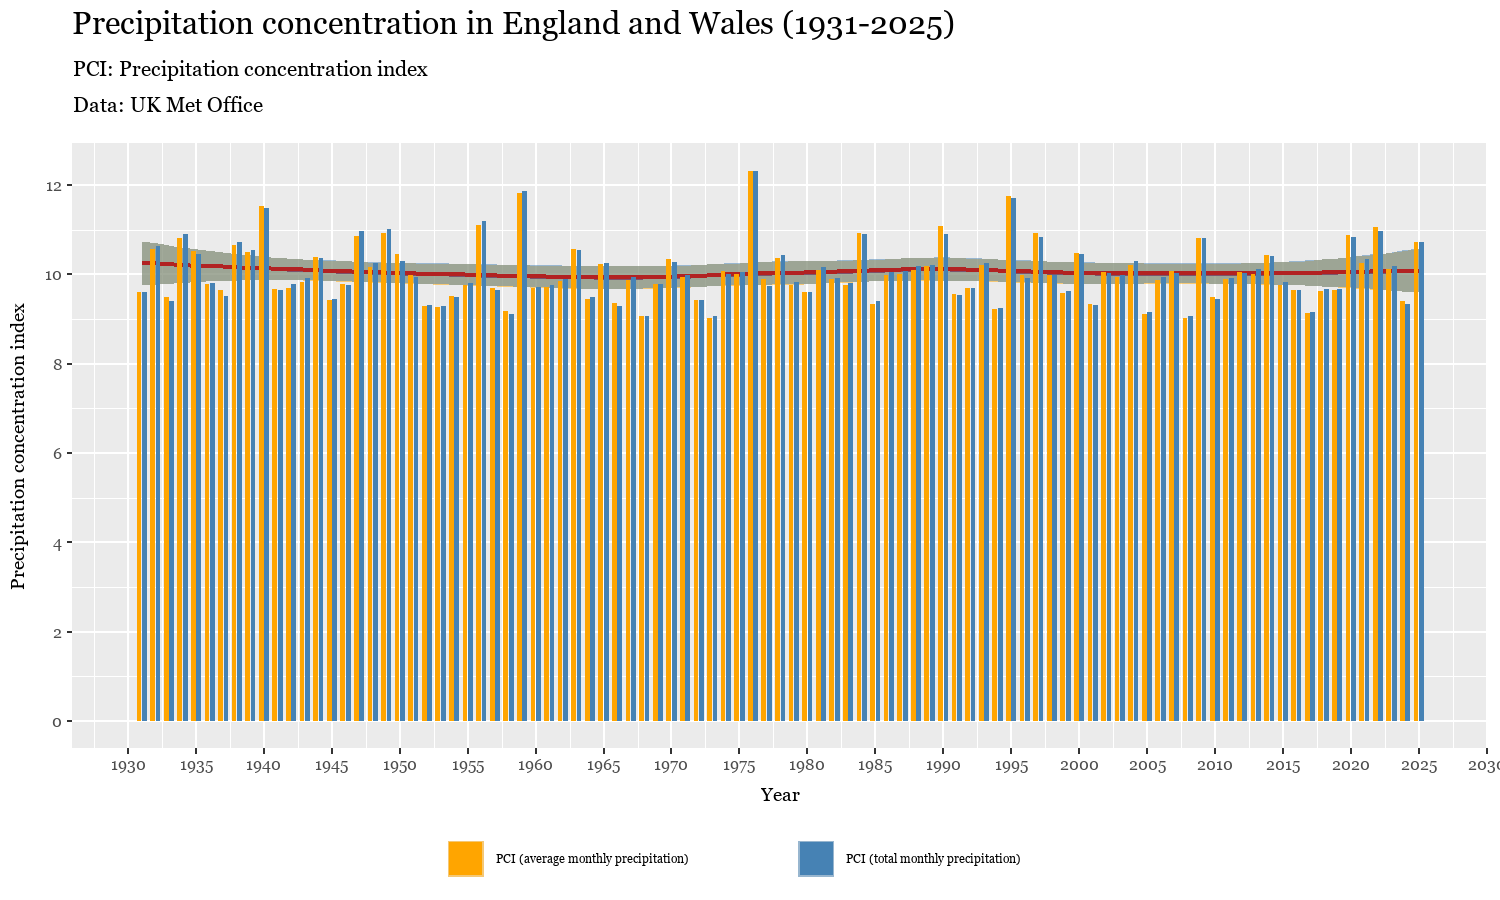

In [29]:
PCI |>
    ggplot(aes(x = year, y = val, fill = var)) + 
        geom_smooth(method = "loess", formula = "y ~ x", alpha = 0.5, colour = "firebrick") +
        geom_col(position = position_dodge(width = 0.8), width = 0.7) +
        scale_fill_manual(
            values = c(pci_avg = "orange", pci_sum = "steelblue"),
            labels = c(pci_avg = "PCI (average monthly precipitation)", pci_sum = "PCI (total monthly precipitation)")
        ) +
        scale_x_continuous(breaks = scales::breaks_width(5)) +
        scale_y_continuous(breaks = scales::breaks_width(2)) +
        guides(fill = guide_legend(title = NULL, nrow = 1)) +
        labs(
            title = "Precipitation concentration in England and Wales (1931-2025)",
            subtitle = "PCI: Precipitation concentration index\nData: UK Met Office",
            x = "Year",
            y = "Precipitation concentration index"
        ) +
        gen_theme(legend = "bottom")


Precipitation concentration index ought to show us changes in the distribution within individual years. The graph does not reveal any changes. This may be obscured by the high-level view of the bars.

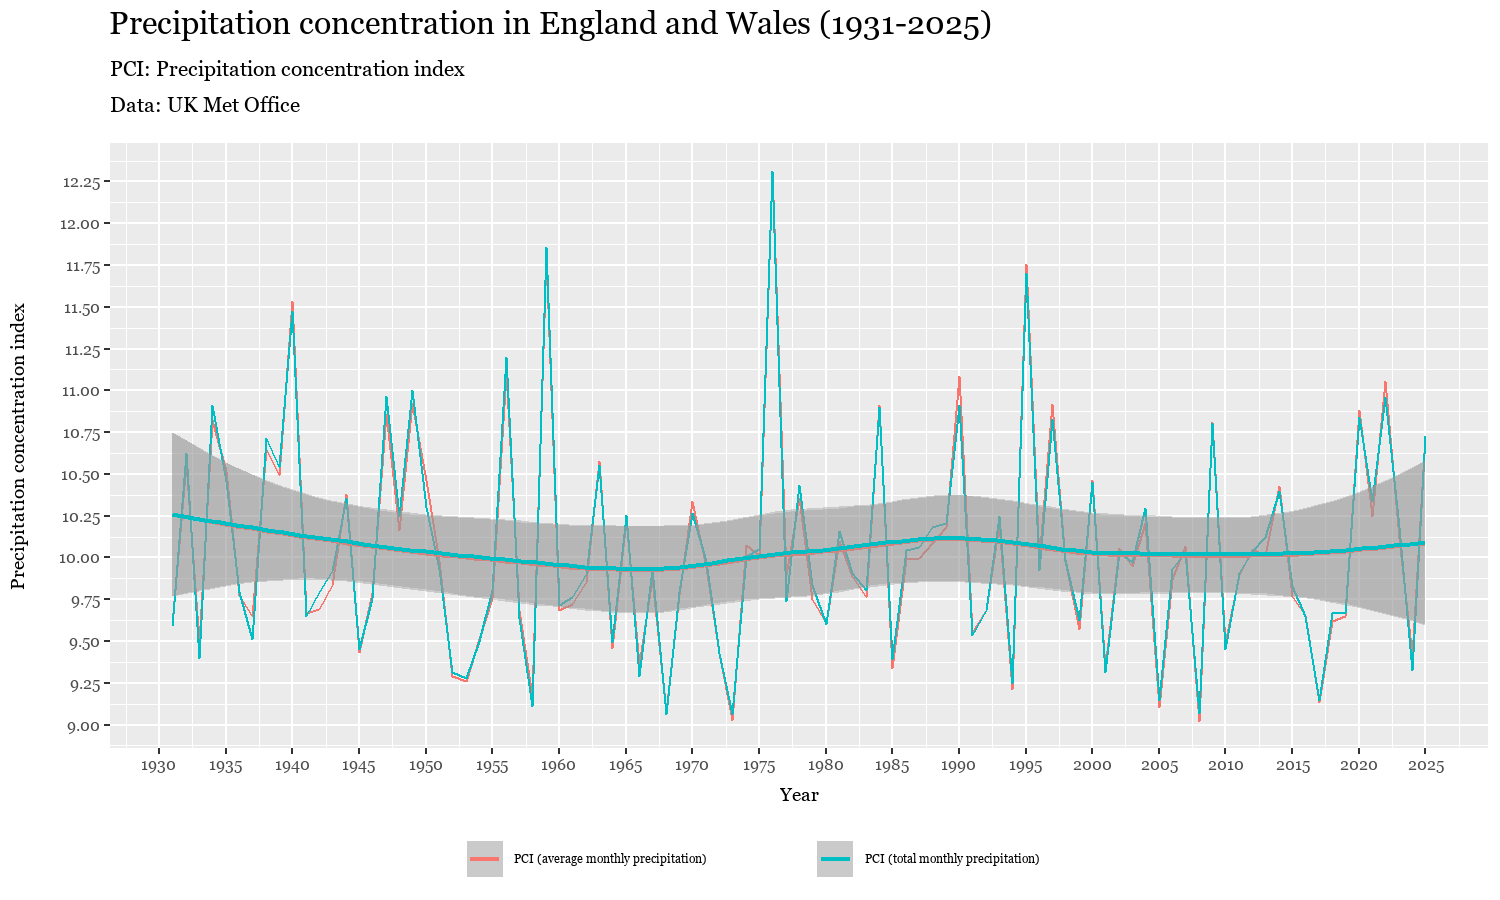

In [30]:
PCI |>
    ggplot(aes(x = year, y = val, colour = label)) +
        geom_line() + 
        geom_smooth(method = "loess", formula = "y ~ x") +
        labs(
            title = "Precipitation concentration in "
        ) +
    scale_x_continuous(breaks = scales::breaks_width(5)) +
    scale_y_continuous(breaks = scales::breaks_width(0.25)) +
    guides(colour = guide_legend(title = NULL, nrow = 1)) + 
    labs(
        title = "Precipitation concentration in England and Wales (1931-2025)",
        subtitle = "PCI: Precipitation concentration index\nData: UK Met Office",
        x = "Year",
        y = "Precipitation concentration index"
    ) +
    gen_theme(legend = "bottom")

PCI cannot show us shifts in precipitation between months, but aggregates the spread across them within any given year. We can see some notable spikes in this close-up on the same index, but the level is more or less constant as it, of course, is in the bar chart above.

## 8. Statistical tests

In this section, we apply the [Mann-Kendall and Sen slope tests](https://cran.r-project.org/web/packages/trend/trend.pdf) to each of the indices calculated above to formally test for the presence of a trend in the data.

In [32]:
indices <- list(
    very_wet_days = very_wet_days |> select(n),
    R95p = R95p |> select(total),
    CDD = CDD |> select(cdd),
    CWD = CWD |> select(cwd),
    R10 = R10 |> select(n),
    R20 = R20 |> select(n),
    PCI_avg = PCI |> filter(var == "pci_avg") |> select(val),
    PCI_total = PCI |> filter(var == "pci_sum") |> select(val)
)

stats_list <- list() 

for (name in names(indices)) {
    vec <- indices[[name]] |> pull()
    MK <- mk.test(vec)
    Sen <- sens.slope(vec)

    stats_list[[name]] <- tibble(
        index = name,
        mk_tau = MK$estimates[["tau"]],
        mk_stat = MK$estimates[["S"]],
        mk_sd = sqrt(MK$estimates[["varS"]]),
        #mk_pval = MK$p.value,
        sen_slope = Sen$estimates[["Sen's slope"]],
        sen_stat = Sen$statistic,
        sen_ci_lo = Sen$conf.int[1],
        sen_ci_hi = Sen$conf.int[2],
        p_value = Sen$p.value

    )
}

stats_df <- stats_list |>
    bind_rows() |>
    mutate(
        p_fdr = p.adjust(p_value, method = "BH"),
        p_bonferroni = p.adjust(p_value, method = "bonferroni"),
        across(
            .cols = where(is.numeric),
            .fns = ~ round(.x, 4)
        )
    )

tldr_df <- stats_df |>
    mutate(
        significance = case_when(
            p_fdr <= 0.001 ~ "***",
            p_fdr <= 0.01 ~ "**",
            p_fdr <= 0.05 ~ "*",
            p_fdr <= 0.1 ~ ".",
            .default = ""
        ),
        description = case_when(
            index == "very_wet_days" ~ "Count of very wet days (>95th pct)",
            index == "R95p" ~ "Total precip on very wet days (>95th pct)",
            index == "CDD" ~ "Max consecutive dry days (<1mm)",
            index == "CWD" ~ "Max consecutive wet days (\u22651mm)",
            index == "R10" ~ "Count of heavy precip days (\u226510mm)",
            index == "R20" ~ "Count of very heavy precip days (\u226520mm)",
            index == "PCI_avg" ~ "Precip concentration index (monthly averages)",
            index == "PCI_total" ~ "Precip concentration index (monthly totals)",
            .default = ""
        )
    ) |>
    select(index, significance, description)

cat("\nStatistical evidence of a trend in extreme precipitation indices for England and Wales (1931-2026):\n")
stats_df

cat("\ntl;dr tab:\n")
print(tldr_df)


Statistical evidence of a trend in extreme precipitation indices for England and Wales (1931-2026):


index,mk_tau,mk_stat,mk_sd,sen_slope,sen_stat,sen_ci_lo,sen_ci_hi,p_value,p_fdr,p_bonferroni
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
very_wet_days,0.1712,751,314.4482,0.0323,2.3851,0.0000,0.0625,0.0171,0.0683,0.1366
R95p,0.1763,804,315.9325,0.5678,2.5417,0.1458,1.0281,0.0110,0.0683,0.0883
CDD,-0.0554,-245,314.8222,0.0000,-0.7750,-0.0545,0.0185,0.4383,0.5844,1.0000
CWD,0.1106,490,314.9942,0.0284,1.5524,0.0000,0.0656,0.1206,0.2411,0.9645
R10,0.0982,435,314.9968,0.0245,1.3778,0.0000,0.0649,0.1683,0.2692,1.0000
R20,0.1793,266,148.8646,0.0000,1.7801,0.0000,0.0000,0.0751,0.2001,0.6004
PCI_avg,-0.0069,-31,311.0332,-0.0002,-0.0965,-0.0050,0.0041,0.9232,0.9949,1.0000
PCI_total,0.0007,3,311.0332,0.0000,0.0064,-0.0048,0.0046,0.9949,0.9949,1.0000



tl;dr tab:
# A tibble: 8 × 3
  index         significance description                                  
  <chr>         <chr>        <chr>                                        
1 very_wet_days "."          Count of very wet days (>95th pct)           
2 R95p          "."          Total precip on very wet days (>95th pct)    
3 CDD           ""           Max consecutive dry days (<1mm)              
4 CWD           ""           Max consecutive wet days (≥1mm)              
5 R10           ""           Count of heavy precip days (≥10mm)           
6 R20           ""           Count of very heavy precip days (≥20mm)      
7 PCI_avg       ""           Precip concentration index (monthly averages)
8 PCI_total     ""           Precip concentration index (monthly totals)  


These data frames collect Mann-Kendall and Sen slope statistics for all eight measures graphed above. We are therefore testing eight hypotheses. Furthermore, since the indices are computed from the same series, they are jointly driven by the same underlying climatic and weather phenomena, and we are therefore testing eight correlated hypotheses. The p-values therefore have to be adjusted to compensate for the increased probability of a false positive and for the indices' dependence.

Taking the FDR-adjusted p-value for our measure of significance, we can conclude that the count of very wet days and the total precipitation on very wet days (R95p) - both practically collinear series - show a suggestive but not conventionally significant 5% threshold.

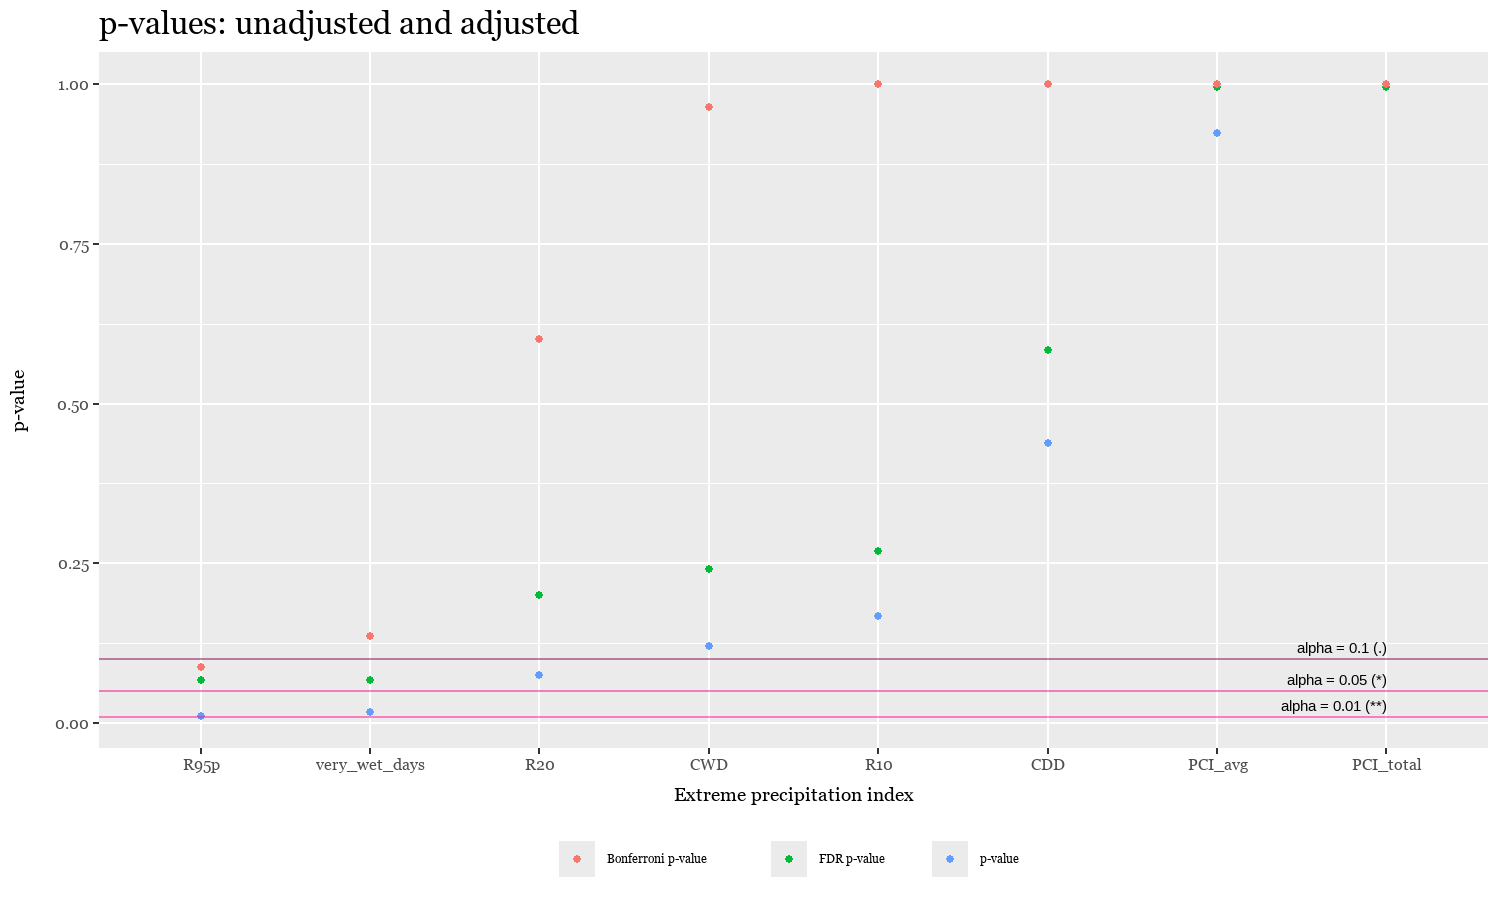

In [33]:
stats_df |>
    arrange(p_value) |>
    mutate(
        rank = row_number(),
        index = factor(index, levels = index, ordered = TRUE),
    ) |>
    pivot_longer(
        cols = starts_with("p_"),
        values_to = "val",
        names_to = "var"
    ) |>
    mutate(
        label = case_when(
            str_detect(var, "bon") ~ "Bonferroni p-value", # p = p \times m
            str_detect(var, "fdr") ~ "FDR p-value", # p_{fdr,i} = \frac{p_i \times m}{i}
            str_detect(var, "val") ~ "p-value",
            .default = ""
        )
    ) |>
    ggplot(aes(x = index, y = val, colour = label)) + 
        geom_point() + 
        geom_hline(yintercept = 0.1, alpha = 0.5, colour = "deeppink4") +
        annotate("text", x = 8, y = 0.11, label = "alpha = 0.1 (.)", hjust = 1, vjust = 0) +
        geom_hline(yintercept = 0.05, alpha = 0.5, colour = "deeppink2") +
        annotate("text", x = 8, y = 0.06, label = "alpha = 0.05 (*)", hjust = 1, vjust = 0) +
        geom_hline(yintercept = 0.01, alpha = 0.5, colour = "deeppink") +
        annotate("text", x = 8, y = 0.02, label = "alpha = 0.01 (**)", hjust = 1, vjust = 0) +
        labs(
            title = "p-values: unadjusted and adjusted",
            x = "Extreme precipitation index",
            y = "p-value",
            colour = ""
        ) + 
        guides(fill = guide_legend(title = NULL, nrow = 1)) + 
        gen_theme(legend = "bottom")

We can see that two FDR-adjusted p-values clear the 10% threshold but fail to cross the stricter, conventionally accepted 5% benchmark.

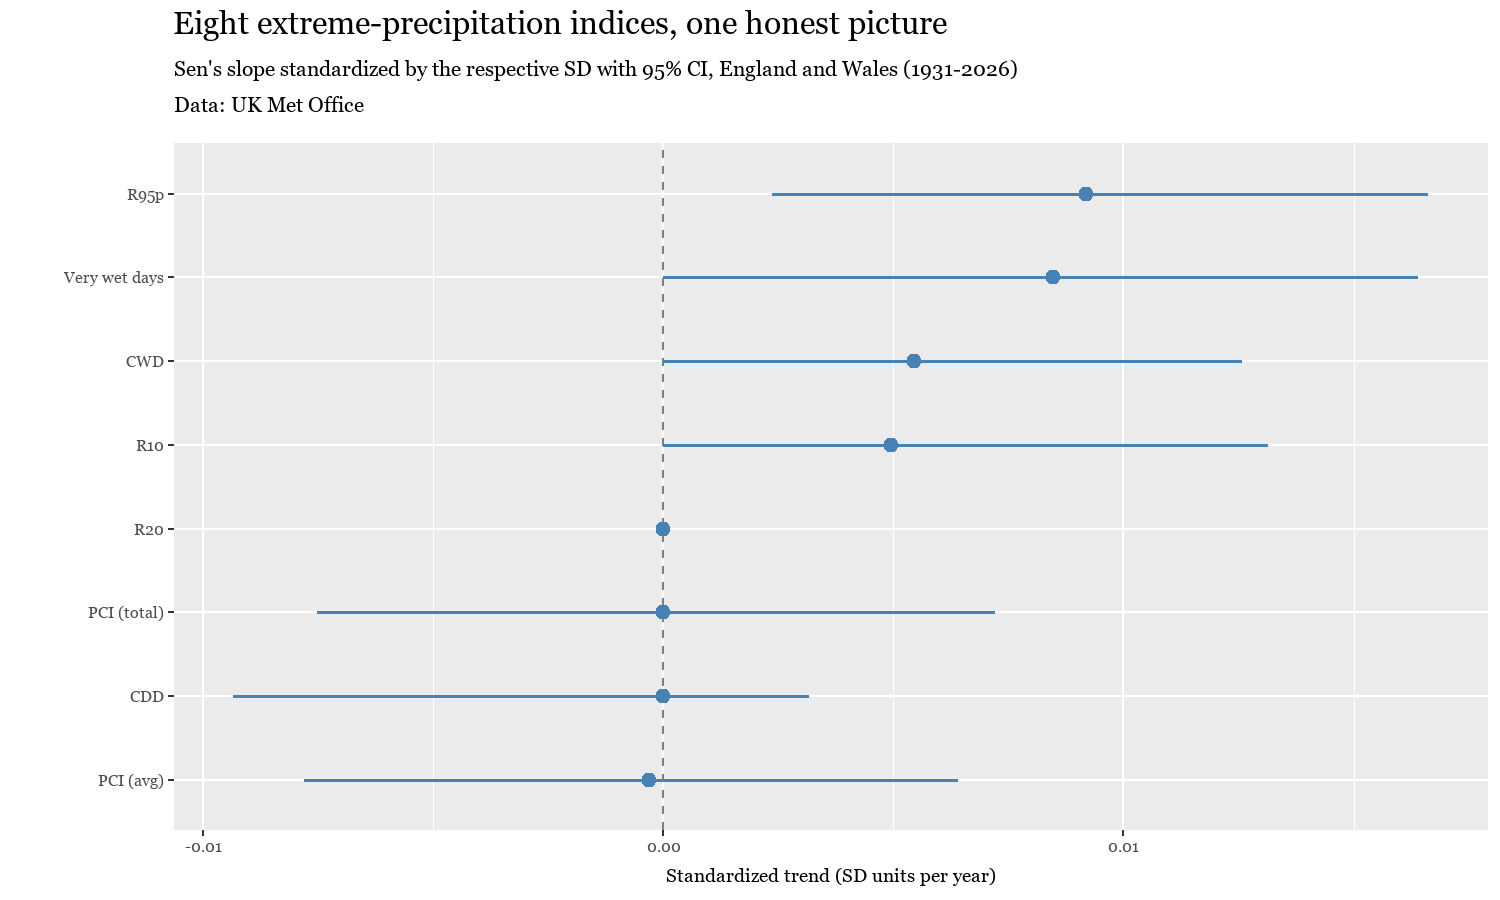

In [34]:
# Standardize Sen's slope by each index's own SD, so all 8 sit on one comparable x-axis
index_sd <- map_dbl(indices, ~ sd(pull(.x)))

forest_df <- stats_df |>
    mutate(
        sd_index = index_sd[index],
        std_slope = sen_slope / sd_index,
        std_ci_lo = sen_ci_lo / sd_index,
        std_ci_hi = sen_ci_hi / sd_index,
        fdr_pass = p_fdr <= 0.05,
        label = case_when(
            index == "very_wet_days" ~ "Very wet days",
            index == "R95p" ~ "R95p",
            index == "CDD" ~ "CDD",
            index == "CWD" ~ "CWD",
            index == "R10" ~ "R10",
            index == "R20" ~ "R20",
            index == "PCI_avg" ~ "PCI (avg)",
            index == "PCI_total" ~ "PCI (total)",
            .default = index
        ),
        label = fct_reorder(label, std_slope)
    )

forest_df |>
    ggplot(aes(x = std_slope, y = label)) +
        geom_vline(xintercept = 0, colour = "grey50", linetype = "dashed") +
        geom_pointrange(aes(xmin = std_ci_lo, xmax = std_ci_hi), colour = "steelblue", size = 0.6, linewidth = 0.8) +
        labs(
            title = "Eight extreme-precipitation indices, one honest picture",
            subtitle = "Sen's slope standardized by the respective SD with 95% CI, England and Wales (1931-2026)\nData: UK Met Office",
            x = "Standardized trend (SD units per year)",
            y = NULL
        ) +
        gen_theme()

The headline graph displays the slope point estimates normalised by each index's own standard deviation and confidence intervals. Echoing the collected statistics above, total precipitation on very wet days (R95p) alone shows significance. The tally of very wet days, the count of wet days and the count of days seeing precipitation above 10 and 20 mm each approach but do not clear the zero slope mark (the null).

## 9. Conclusions

Ocular analysis of the time series and extreme precipitation indices tentatively pointed towards a trending change in weather patterns. This has not been borne out by statistical tests we have conducted on the index series, six of which do not pass any threshold of significance and the last two of which, namely our very wet days series, pass only the more lenient 10% threshold. We therefore have to conclude that we have not found convincing evidence of evolving patterns in precipitation.